✓ Bloomberg connected (localhost:8194)
  Auto-discovering universe for GMD AU Equity...
    ├─ market=AU, sector=Broad → local index AS51 Index: 200 names
    ⚠ TW50 Index returned 0 members (licence-gated?) — trying fallback
    ├─ running BICS + GICS dual-taxonomy cross-country search...
    ├─ industry matches captured: 190 names
    ├─ Bloomberg peers (incl. 2nd degree): 24 names
    ├─ liquidity filter: dropped 70 names below $1.0bn market cap
    ✓ final merged universe: 283 candidates
  [Fix 49] adding 87 PAST index members missing from today's universe (delisted / dropped names — survivorship fix)
  ✓ point-in-time membership: 14 snapshots, 269 names ever members
  ✓ 1096 price rows × 371 tickers
  ✓ USD market caps stored for 346 tickers
  ✓ point-in-time market-cap paths for 371 tickers
Using pre-downloaded data: 1096 rows × 371 tickers (no API calls)
  [Fix 49] point-in-time index membership active — 14 snapshots, 269 names ever members
  [Fix 44] point-in-time size filterin

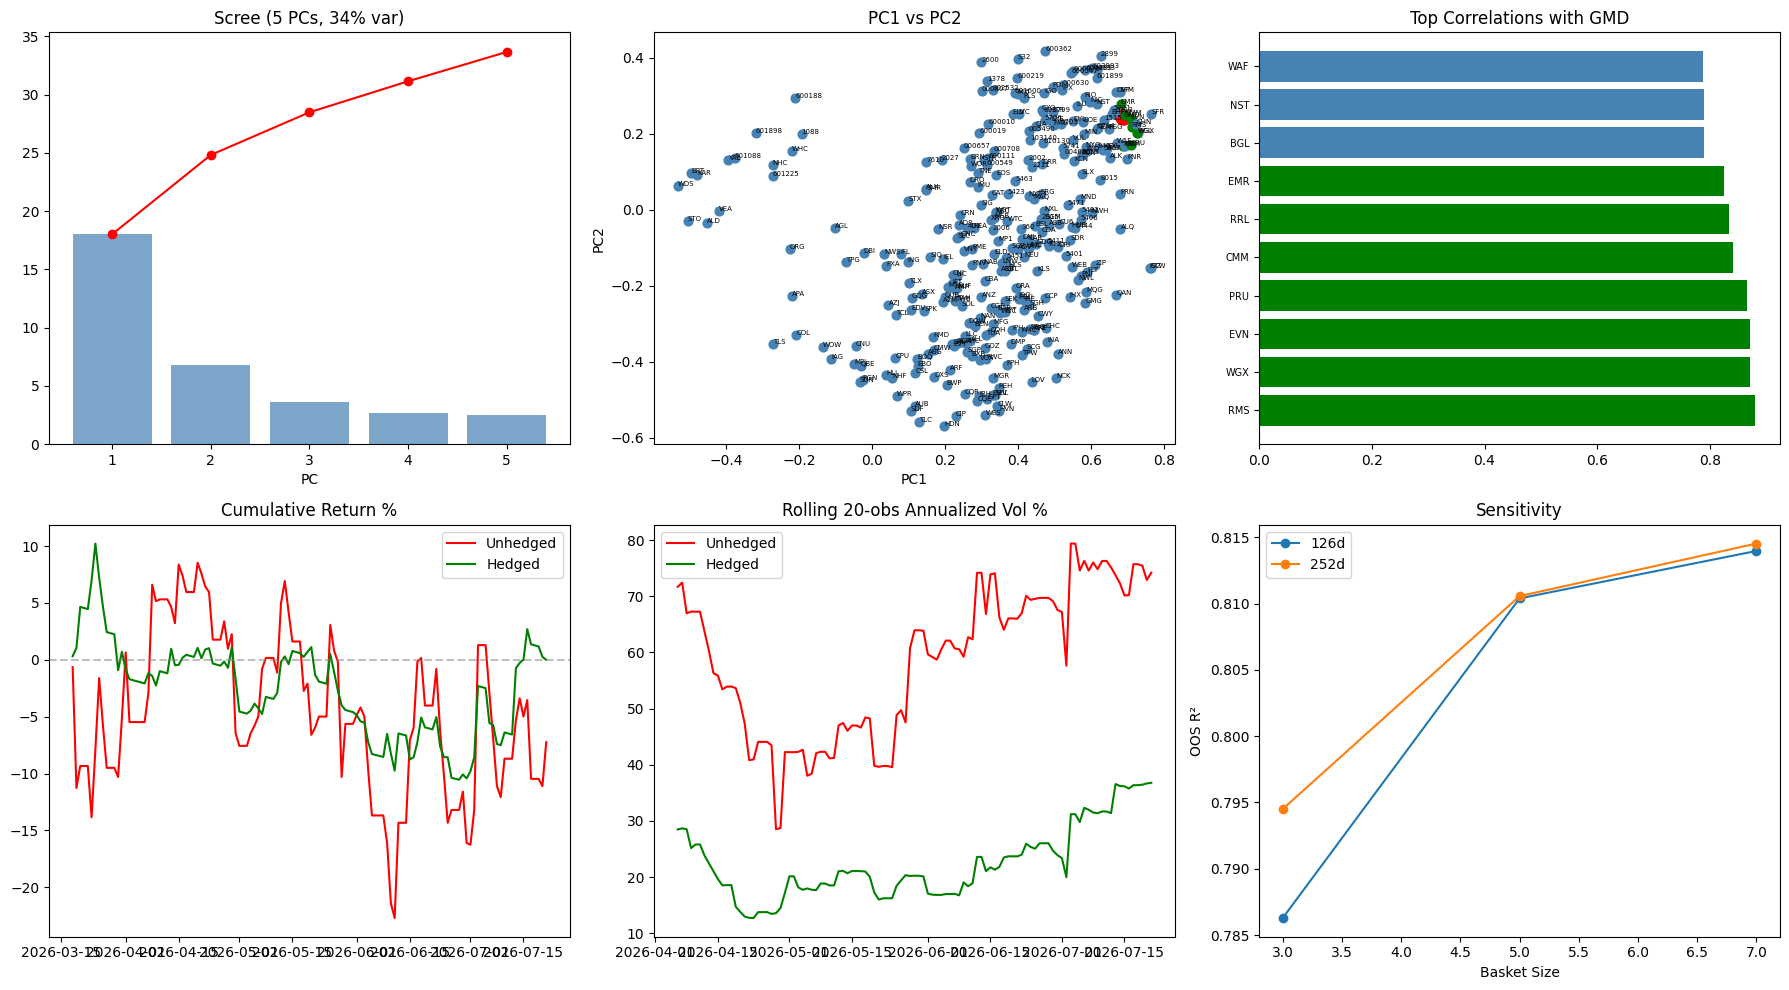


PCA HEDGE FINDER — GMD   (2026-07-21 14:49)
Universe: 322 candidates | return frequency: daily | Ridge alpha: CV-selected

[1] HOW RELIABLE IS THIS HEDGE?  (higher = better)
  Full-data CV mean OOS R² :  0.814  (± 0.051, 5 folds)
  Full-data CV vol red     :  57.4%
  ★ THIS config, unseen OOS:  0.829 ± 0.028  over 3 windows × 42d | vol red=59.1%
  Pipeline nested OOS R²   :  0.828 ± 0.030  (selection re-run before each window)
  In-sample R² 0.838 vs unseen 0.829 → ✓ generalizes well
  ⚠ NOTE: in 2/3 unseen windows the pipeline selected [lb=252, pc=auto, size=7],
    not the live selection [lb=126, pc=auto, size=7] — consider the top-5 section before trading.
──────────────────────────────────────────────────────────────────────────────
  Selected params: lookback=126d | PCs=auto (final=5) | basket=7

[2] HEDGE RECIPE — per $100 long GMD, execute:
  ┌────────┬────────┬────────────┬───────────────┬────────┐
  │ ACTION │ AMOUNT │ INSTRUMENT │ FULL TICKER   │ FORCED │
  ├────────┼───────

In [1]:

# =============================================================================
# CELL 1: SETUP (run once)
# =============================================================================
 
import numpy as np
import pandas as pd
import blpapi
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from statsmodels.tsa.stattools import adfuller
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
 
warnings.filterwarnings('ignore')
 
RIDGE_ALPHAS = np.logspace(-4, 2, 25)
 
# ─────────────────────────────────────────────────────────────────────────────
# INDEX MAP: (market_code, sector_keyword) → Bloomberg Index Ticker
# [Fix 19] The key is the LISTING MARKET of the target (derived from its
# exchange code), except for ADRs where country-of-risk is used as fallback.
# ─────────────────────────────────────────────────────────────────────────────
INDEX_MAP = {
    # US — official S&P 500 sector indices (INDX_MEMBERS friendly)
    ('US', 'Broad'):                 'SPX Index',
    ('US', 'Technology'):            'NDX Index',
    ('US', 'Communication'):         'S5TELS Index',
    ('US', 'Financials'):            'S5FINL Index',
    ('US', 'Health Care'):           'S5HLTH Index',
    ('US', 'Energy'):                'S5ENRS Index',
    ('US', 'Consumer Discretionary'): 'S5COND Index',
    # CN — used for onshore listings AND as the ADR fallback
    # (US-listed China names → HXC, the Nasdaq Golden Dragon index)
    ('CN', 'Broad'):                 'SHSZ300 Index',   # CSI 300 (onshore)
    ('CN', 'Technology'):            'HXC Index',
    ('CN', 'Communication'):         'HXC Index',
    ('CN', 'Consumer Discretionary'): 'HXC Index',
    # HK — HK-listed names (incl. CN-domiciled ones like Tencent/Meituan)
    ('HK', 'Broad'):                 'HSI Index',       # Hang Seng
    ('HK', 'Technology'):            'HSTECH Index',    # Hang Seng Tech
    ('HK', 'Communication'):         'HSTECH Index',
    ('HK', 'Consumer Discretionary'): 'HSTECH Index',
    ('HK', 'Financials'):            'HSI Index',
    # Europe
    ('EU', 'Broad'):                 'SXXP Index',      # Stoxx Europe 600
    ('DE', 'Broad'):                 'DAX Index',
    ('FR', 'Broad'):                 'CAC Index',
    ('GB', 'Broad'):                 'UKX Index',
    # Japan — TOPIX (broader, cap-weighted) instead of Nikkei
    ('JP', 'Broad'):                 'TPX Index',
    ('JP', 'Technology'):            'TPX Index',
    ('JP', 'Financials'):            'TPNBNK Index',
    # Korea, India, Australia, Taiwan
    ('KR', 'Broad'):                 'KOSPI2 Index',
    ('KR', 'Technology'):            'KOSPI2 Index',
    ('IN', 'Broad'):                 'NIFTY Index',
    ('IN', 'Technology'):            'NIFTY Index',
    ('IN', 'Financials'):            'NIFTY Index',
    ('AU', 'Broad'):                 'AS51 Index',
    # [Fix 37] TW50 INDX_MEMBERS is licence-gated on many terminals and
    # returns 0 members — which silently stripped every TAIEX large cap
    # (2330 TT included) from the universe. Values may now be a tuple of
    # fallbacks, tried in order until one returns members.
    ('TW', 'Broad'):                 ('TW50 Index', 'TWSE Index'),
    ('TW', 'Technology'):            ('TW50 Index', 'TWSE Index'),
}
 
# ─────────────────────────────────────────────────────────────────────────────
# CONTROL ETFS by market (added to the universe as benchmark hedges)
# Each market lists US-listed wrappers AND locally-listed ETFs. Locally-listed
# ETFs trade in the same timezone and currency as local targets, so they avoid
# the async-trading bias and FX mismatch that US-listed wrappers carry.
# ─────────────────────────────────────────────────────────────────────────────
CONTROL_ETFS = {
    'CN': [
        # US-listed wrappers
        'KWEB US Equity', 'FXI US Equity', 'MCHI US Equity',
        'ASHR US Equity', 'CQQQ US Equity', 'GXC US Equity',
        # locally listed
        '510300 CH Equity',   # Huatai-PB CSI 300 ETF (Shanghai)
        '510050 CH Equity',   # ChinaAMC SSE 50 ETF (Shanghai)
        '2823 HK Equity',     # iShares FTSE China A50 (HK)
        '3188 HK Equity'],    # ChinaAMC CSI 300 (HK)
    'US': [
        # broad / size
        'SPY US Equity', 'QQQ US Equity', 'IWM US Equity', 'DIA US Equity',
        # style factors
        'MTUM US Equity', 'VLUE US Equity', 'QUAL US Equity',
        'USMV US Equity', 'VUG US Equity',
        # core sectors
        'XLK US Equity', 'XLF US Equity', 'XLV US Equity', 'XLE US Equity',
        'XLY US Equity', 'XLC US Equity', 'XLI US Equity'],
    'JP': ['EWJ US Equity', 'DXJ US Equity', 'BBJP US Equity',
           '1306 JT Equity',   # NEXT FUNDS TOPIX ETF (Tokyo)
           '1321 JT Equity'],  # NEXT FUNDS Nikkei 225 ETF (Tokyo)
    'HK': ['EWH US Equity', 'FLHK US Equity',
           '2800 HK Equity',   # Tracker Fund of Hong Kong (HSI)
           '2828 HK Equity',   # Hang Seng China Enterprises ETF
           '3033 HK Equity'],  # CSOP Hang Seng TECH ETF
    'KR': ['EWY US Equity', 'FLKR US Equity',
           '069500 KS Equity'],  # Samsung KODEX 200 (Seoul)
    'TW': ['0050 TT Equity',     # Yuanta Taiwan Top 50 (Taipei)
           '006208 TT Equity'],  # Fubon Taiwan 50 (Taipei)
    'IN': ['INDA US Equity', 'EPI US Equity', 'SMIN US Equity',
           'NIFTYBEES IN Equity'],  # Nippon India Nifty 50 BeES (NSE)
    'DE': ['EWG US Equity',
           'EXS1 GR Equity'],   # iShares Core DAX UCITS (Xetra)
    'GB': ['EWU US Equity',
           'ISF LN Equity',     # iShares Core FTSE 100 (London)
           'VUKE LN Equity'],   # Vanguard FTSE 100 (London)
    'FR': ['EWQ US Equity',
           'CAC FP Equity'],    # Amundi CAC 40 UCITS (Paris)
    'AU': ['EWA US Equity',
           'STW AU Equity',     # SPDR S&P/ASX 200 (ASX)
           'IOZ AU Equity'],    # iShares Core S&P/ASX 200 (ASX)
    # [Fix 43] cross-market style-factor wrappers, added to EVERY universe
    # so momentum / size / value / quality / low-vol have candidates even
    # for non-US targets (US-listed -> treated as async, 2-day returns).
    'FACTOR': ['MTUM US Equity', 'VLUE US Equity', 'QUAL US Equity',
               'USMV US Equity', 'SIZE US Equity', 'IWM US Equity',
               'SPY US Equity', 'IMTM US Equity', 'IVLU US Equity',
               'IQLT US Equity', 'ACWV US Equity'],
    'GLOBAL': ['ACWI US Equity', 'EEM US Equity', 'EFA US Equity', 'URTH US Equity'],
}
 
# [Fix 14] ETF whitelist (short names) auto-generated — always in sync
ETF_SHORT_SET = {t.split(' ')[0] for lst in CONTROL_ETFS.values() for t in lst}
 
# ─────────────────────────────────────────────────────────────────────────────
# Exchange code mappings
# ─────────────────────────────────────────────────────────────────────────────
EXCH_MAP = {
    'UQ': 'US', 'UW': 'US', 'UN': 'US', 'US': 'US', 'UA': 'US', 'UP': 'US',
    'HK': 'HK', 'LN': 'LN', 'JT': 'JP', 'GR': 'GR', 'GY': 'GR',
    'FP': 'FP', 'IM': 'IM', 'SM': 'SM', 'AU': 'AU', 'AV': 'AV',
    'IN': 'IN', 'IB': 'IN', 'SJ': 'SJ', 'KS': 'KS', 'KP': 'KS',
    'TT': 'TT', 'SP': 'SP', 'MK': 'MK', 'CH': 'CH',
    # [Fix 32] previously-unmapped codes. 'AT' (ASX single-exchange code,
    # e.g. 'ELS AT Equity') fell through to 'OTHER' while the AU-listed ETFs
    # ('STW AU') mapped to APAC — so Australian stocks and their own local
    # ETFs landed in DIFFERENT timezone groups.
    'AT': 'AU', 'AH': 'AU',            # ASX
    'KQ': 'KS',                        # KOSDAQ
    'C1': 'CH', 'C2': 'CH',            # China Connect lines
    'NA': 'NA', 'SW': 'SW', 'SE': 'SW',  # Amsterdam, SIX
}
 
# [Fix 19] Normalized exchange code → market key used in INDEX_MAP/CONTROL_ETFS
EXCH_TO_MARKET = {
    'US': 'US', 'HK': 'HK', 'JP': 'JP', 'CH': 'CN', 'KS': 'KR', 'TT': 'TW',
    'IN': 'IN', 'AU': 'AU', 'GR': 'DE', 'LN': 'GB', 'FP': 'FR',
    'IM': 'EU', 'SM': 'EU', 'AV': 'EU', 'SJ': 'EU',
    'NA': 'EU', 'SW': 'EU',            # [Fix 32]
}
 
# [Fix 32] Approximate cash-session CLOSING HOUR in UTC per normalized
# exchange code (standard time; the ~1h DST drift is absorbed by the
# tolerance). This replaces the old AMER/EMEA/APAC buckets, which were too
# coarse in both directions: Taipei (05:30 UTC) and Mumbai (10:00 UTC) were
# called synchronous because both were 'APAC', while any unmapped exchange
# fell into an 'OTHER' bucket that the async-bias check silently ignored.
EXCH_CLOSE_UTC = {
    'US': 21.0,                        # NYSE / Nasdaq 16:00 ET
    'LN': 16.5,                        # LSE 16:30
    'GR': 16.5, 'FP': 16.5, 'IM': 16.5, 'SM': 16.5, 'AV': 16.5,
    'NA': 16.5, 'SW': 16.5,            # continental Europe ~17:30 CET
    'SJ': 15.0,                        # JSE 17:00 SAST
    'TT': 5.5,                         # TWSE 13:30
    'JP': 6.0,                         # TSE 15:00 JST
    'AU': 6.0,                         # ASX 16:00 AEST
    'KS': 6.5,                         # KRX 15:30 KST
    'CH': 7.0,                         # SSE / SZSE 15:00 CST
    'HK': 8.0,                         # HKEX 16:00
    'SP': 9.0, 'MK': 9.0,              # SGX / Bursa 17:00 local
    'IN': 10.0,                        # NSE / BSE 15:30 IST
}
 
 
def _exch_of(full_ticker):
    """'700 HK Equity' → 'HK' (normalized via EXCH_MAP; 'JT' → 'JP' etc.)."""
    parts = full_ticker.split(' ')
    if len(parts) >= 2:
        return EXCH_MAP.get(parts[-2], parts[-2])
    return 'US'
 
 
def _close_utc_of(full_ticker):
    """[Fix 32] Approximate closing hour (UTC) of the ticker's exchange,
    or None when the exchange is unknown."""
    return EXCH_CLOSE_UTC.get(_exch_of(full_ticker))
 
 
def _close_gap_hours(a, b):
    """[Fix 32] Circular distance in hours between two closing times
    (a 23h gap is really a 1h gap on the clock)."""
    d = abs(a - b) % 24.0
    return min(d, 24.0 - d)
 
 
def _fmt_mktcap(mm):
    """[Fix 35] Format a USD-millions floor as '$750mm' / '$5.0bn'. The old
    message divided by 1000 and always printed 'bn', so a 50mm floor showed
    up as '$0bn'."""
    return f"${mm / 1000:.1f}bn" if mm >= 1000 else f"${mm:.0f}mm"
 
 
def _apply_exclusions(tickers, exclude):
    """[Fix 36] Manual filter-out of securities the user does not want as
    hedge candidates. Entries match the full ticker ('3156 JP Equity',
    case-insensitive, ' Equity' optional) or the bare short name ('3156').
    Returns (kept, removed)."""
    if not exclude:
        return list(tickers), []
    ex = {str(e).upper().replace(' EQUITY', '').strip() for e in exclude}
    kept, removed = [], []
    for tk in tickers:
        cu = tk.upper().replace(' EQUITY', '').strip()
        if cu in ex or cu.split(' ')[0] in ex:
            removed.append(tk)
        else:
            kept.append(tk)
    return kept, removed
 
 
def _resolve_force_include(force_include, columns, target_ticker):
    """[Fix 40] Resolve the user's must-have securities against the
    downloaded price columns. Entries match the full ticker
    ('0050 TT Equity', case-insensitive, ' Equity' optional) or the bare
    short name ('0050'). The target itself is ignored.
    Returns (resolved_full_tickers, unresolved_entries)."""
    if not force_include:
        return [], []
    resolved, unresolved = [], []
    for f in force_include:
        fu = str(f).upper().replace(' EQUITY', '').strip()
        hit = None
        for c in columns:
            cu = c.upper().replace(' EQUITY', '').strip()
            if cu == fu or cu.split(' ')[0] == fu:
                hit = c
                break
        if hit is None:
            unresolved.append(f)
        elif hit != target_ticker:
            resolved.append(hit)
    out, seen = [], set()
    for r in resolved:                 # dedupe, keep user order
        if r not in seen:
            out.append(r)
            seen.add(r)
    return out, unresolved
 
 
def _print_table(headers, rows, indent='  '):
    """[Fix 41] Render rows as a boxed unicode table — reader-friendly
    replacement for the raw column printouts. Layout only; the values
    printed are exactly the same as before."""
    rows = [[str(x) for x in r] for r in rows]
    widths = [max(len(headers[i]), max((len(r[i]) for r in rows), default=0))
              for i in range(len(headers))]
 
    def hline(l, m, r):
        print(indent + l + m.join('─' * (w + 2) for w in widths) + r)
 
    def prow(vals):
        cells = []
        for i, v in enumerate(vals):
            pad = ' ' * (widths[i] - len(v))
            # right-align $-amount cells, left-align everything else
            if v[:1] == '$':
                cells.append(f' {pad}{v} ')
            else:
                cells.append(f' {v}{pad} ')
        print(indent + '│' + '│'.join(cells) + '│')
 
    hline('┌', '┬', '┐')
    prow(headers)
    hline('├', '┼', '┤')
    for r in rows:
        prow(r)
    hline('└', '┴', '┘')
 
 
def _market_of(target_ticker, country_iso):
    """[Fix 19] Market key for index/ETF lookups.
 
    Rule: use the LISTING market derived from the exchange code. The only
    exception is a US listing whose country of risk is not the US (an ADR,
    e.g. BABA US with COUNTRY_ISO=CN) — there the country mapping is the
    right 'local' universe (HXC = US-listed China names).
 
    Examples: 700 HK (Tencent, COUNTRY_ISO=CN) → 'HK' → HSTECH/HSI.
              BABA US (COUNTRY_ISO=CN)        → 'CN' → HXC.
              005930 KS (Samsung)             → 'KR' → KOSPI2.
    """
    exch = _exch_of(target_ticker)
    market = EXCH_TO_MARKET.get(exch)
    if exch == 'US' and country_iso != 'US':
        return country_iso
    return market or country_iso
 
 
def _fmt_bbg_ticker(raw):
    """[Fix 1] Normalize 'XXX YY' or 'XXX YY Equity' → 'XXX <exch> Equity'."""
    parts = raw.replace(' Equity', '').split(' ')
    if len(parts) >= 2 and parts[0]:
        return f"{parts[0]} {EXCH_MAP.get(parts[-1], parts[-1])} Equity"
    return None
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Bloomberg helper functions
# ─────────────────────────────────────────────────────────────────────────────
def bbg_connect(host='localhost', port=8194):
    opts = blpapi.SessionOptions()
    opts.setServerHost(host)
    opts.setServerPort(port)
    s = blpapi.Session(opts)
    # [Fix 13] explicit raise instead of assert (assert is stripped under -O)
    if not s.start():
        raise ConnectionError(
            f"Bloomberg session failed to start ({host}:{port}) — "
            "check that the terminal is logged in")
    if not s.openService("//blp/refdata"):
        raise ConnectionError("Failed to open //blp/refdata service")
    print(f"✓ Bloomberg connected ({host}:{port})")
    return s
 
 
# [Fix 3] Lazy session: reconnectable, not frozen into a default argument
SESSION = None
 
def get_session():
    global SESSION
    if SESSION is None:
        SESSION = bbg_connect()
    return SESSION
 
 
def _drain_events(session, on_message, timeout_ms=60000):
    """[Fix 2] Shared event loop: raises on TIMEOUT instead of spinning forever."""
    while True:
        ev = session.nextEvent(timeout_ms)
        if ev.eventType() == blpapi.Event.TIMEOUT:
            raise TimeoutError(
                f"Bloomberg request timed out after {timeout_ms} ms — "
                "check terminal connectivity or reduce the batch size")
        for msg in ev:
            on_message(msg)
        if ev.eventType() == blpapi.Event.RESPONSE:
            break
 
 
def bbg_hist_field(session, tickers, field, start, end):
    """[Fix 44] Generic historical BDH for a single numeric field (e.g.
    'CUR_MKT_CAP'). Same batching / draining as bbg_hist; returns a DataFrame
    keyed by full ticker. Used to build point-in-time market-cap paths so the
    size filter can be applied as-of each backtest window instead of with
    today's cap (look-ahead for names that have changed size)."""
    svc = session.getService("//blp/refdata")
    data, bad = {}, []
    batch = 100
    for i in range(0, len(tickers), batch):
        req = svc.createRequest("HistoricalDataRequest")
        for t in tickers[i:i + batch]:
            req.getElement("securities").appendValue(t)
        req.getElement("fields").appendValue(field)
        req.set("periodicitySelection", "DAILY")
        req.set("startDate", start)
        req.set("endDate", end)
        req.set("nonTradingDayFillOption", "NON_TRADING_WEEKDAYS")
        req.set("nonTradingDayFillMethod", "PREVIOUS_VALUE")
        session.sendRequest(req)
 
        def on_msg(msg):
            if not msg.hasElement("securityData"):
                return
            sd = msg.getElement("securityData")
            sec = sd.getElementAsString("security")
            if sd.hasElement("securityError"):
                bad.append(sec)
                return
            fda = sd.getElement("fieldData")
            recs = []
            for k in range(fda.numValues()):
                fd = fda.getValueAsElement(k)
                try:
                    recs.append({'date': fd.getElementAsDatetime("date"),
                                 'val': fd.getElementAsFloat(field)})
                except Exception:
                    continue
            if recs:
                df = pd.DataFrame(recs)
                df['date'] = pd.to_datetime(df['date'])
                data[sec] = df.set_index('date')['val']
 
        _drain_events(session, on_msg)
    return pd.DataFrame(data)
 
 
def bbg_hist(session, tickers, start, end):
    """Historical PX_LAST. Returns a DataFrame keyed by full ticker.
    Invalid tickers are reported, not silently dropped."""
    svc = session.getService("//blp/refdata")
    data, bad = {}, []
    batch = 100  # keep historical requests reasonably sized
    for i in range(0, len(tickers), batch):
        req = svc.createRequest("HistoricalDataRequest")
        for t in tickers[i:i + batch]:
            req.getElement("securities").appendValue(t)
        req.getElement("fields").appendValue("PX_LAST")
        req.set("periodicitySelection", "DAILY")
        req.set("startDate", start)
        req.set("endDate", end)
        req.set("nonTradingDayFillOption", "NON_TRADING_WEEKDAYS")
        req.set("nonTradingDayFillMethod", "PREVIOUS_VALUE")
        session.sendRequest(req)
 
        def on_msg(msg):
            if not msg.hasElement("securityData"):
                return
            sd = msg.getElement("securityData")
            sec = sd.getElementAsString("security")
            if sd.hasElement("securityError"):          # [Fix 13/15]
                bad.append(sec)
                return
            fda = sd.getElement("fieldData")
            recs = []
            for k in range(fda.numValues()):
                fd = fda.getValueAsElement(k)
                try:
                    recs.append({'date': fd.getElementAsDatetime("date"),
                                 'px': fd.getElementAsFloat("PX_LAST")})
                except Exception:
                    continue
            if recs:
                df = pd.DataFrame(recs)
                df['date'] = pd.to_datetime(df['date'])
                data[sec] = df.set_index('date')['px']
 
        _drain_events(session, on_msg)
    if bad:
        print(f"  ⚠ {len(bad)} invalid tickers dropped (e.g. {bad[:5]})")
    return pd.DataFrame(data)
 
 
def bbg_bulk(session, ticker, field, overrides=None):
    """BDS bulk field — returns a list of dicts (one per row).
    [Fix 49] optional overrides, e.g. {'END_DATE_OVERRIDE': '20240630'} to
    read INDX_MWEIGHT_HIST as of a past date."""
    svc = session.getService("//blp/refdata")
    req = svc.createRequest("ReferenceDataRequest")
    req.getElement("securities").appendValue(ticker)
    req.getElement("fields").appendValue(field)
    if overrides:
        ovr = req.getElement("overrides")
        for k, v in overrides.items():
            o = ovr.appendElement()
            o.setElement("fieldId", k)
            o.setElement("value", str(v))
    session.sendRequest(req)
    rows = []
 
    def on_msg(msg):
        if not msg.hasElement("securityData"):
            return
        arr = msg.getElement("securityData")
        for i in range(arr.numValues()):
            sd = arr.getValueAsElement(i)
            if sd.hasElement("securityError"):
                continue
            fd = sd.getElement("fieldData")
            if fd.hasElement(field):
                bulk = fd.getElement(field)
                for j in range(bulk.numValues()):
                    row = bulk.getValueAsElement(j)
                    d = {}
                    for k in range(row.numElements()):
                        e = row.getElement(k)
                        d[str(e.name())] = str(e.getValue())
                    rows.append(d)
 
    _drain_events(session, on_msg)
    return rows
 
 
def bbg_ref_multi(session, tickers, fields, overrides=None):
    """BDP reference data for many tickers → {full_ticker: {field: value}}.
    [Fix 25] `overrides` is an optional {fieldId: value} dict."""
    svc = session.getService("//blp/refdata")
    result = {}
    batch = 300
    for i in range(0, len(tickers), batch):
        req = svc.createRequest("ReferenceDataRequest")
        for t in tickers[i:i + batch]:
            req.getElement("securities").appendValue(t)
        for f in fields:
            req.getElement("fields").appendValue(f)
        if overrides:
            ovr = req.getElement("overrides")
            for k, v in overrides.items():
                o = ovr.appendElement()
                o.setElement("fieldId", k)
                o.setElement("value", str(v))
        session.sendRequest(req)
 
        def on_msg(msg):
            if not msg.hasElement("securityData"):
                return
            arr = msg.getElement("securityData")
            for j in range(arr.numValues()):
                sd = arr.getValueAsElement(j)
                sec = sd.getElementAsString("security")
                if sd.hasElement("securityError"):
                    continue
                fd = sd.getElement("fieldData")
                result[sec] = {}
                for f in fields:
                    if fd.hasElement(f):
                        try:
                            result[sec][f] = fd.getElementAsString(f)
                        except Exception:
                            try:
                                result[sec][f] = fd.getElementAsFloat(f)
                            except Exception:
                                pass
 
        _drain_events(session, on_msg)
    return result
 
 
def bbg_ref_single(session, ticker, fields):
    return bbg_ref_multi(session, [ticker], fields).get(ticker, {})
 
 
# ─────────────────────────────────────────────────────────────────────────────
# Universe discovery
# ─────────────────────────────────────────────────────────────────────────────
def _index_members(session, spec):
    """[Fix 37] `spec` is one index ticker or a tuple of fallbacks. Returns
    (ticker_used, members) from the first index that yields any members —
    an index that loads but returns 0 members (licence-gated INDX_MEMBERS)
    now falls through instead of silently emptying a universe leg."""
    tickers = [spec] if isinstance(spec, str) else list(spec or [])
    for n, idx_ticker in enumerate(tickers):
        members = []
        try:
            for r in bbg_bulk(session, idx_ticker, 'INDX_MEMBERS'):
                tk = _fmt_bbg_ticker(r.get('Member Ticker and Exchange Code', ''))
                if tk:
                    members.append(tk)
        except Exception as e:
            print(f"    ⚠ failed to read {idx_ticker} members: {e}")
            continue
        if members:
            return idx_ticker, members
        more = " — trying fallback" if n + 1 < len(tickers) else ""
        print(f"    ⚠ {idx_ticker} returned 0 members (licence-gated?){more}")
    return None, []
 
 
def _pit_index_membership(session, index_tickers, start, end, freq_days=91):
    """[Fix 49] Point-in-time index-membership snapshots via INDX_MWEIGHT_HIST
    with an END_DATE_OVERRIDE, roughly quarterly across [start, end]. Returns
    {Timestamp: frozenset(full tickers)} (union across the given indices).
    GRACEFUL FALLBACK: some indices licence-gate this field (e.g. certain
    TW/Asia benchmarks) — any snapshot that fails is skipped, and if NOTHING
    comes back an empty dict is returned with a warning, so the pipeline
    silently reverts to today's-members behavior (survivorship caveat then
    still applies)."""
    idxs = [i for i in dict.fromkeys(index_tickers or []) if i]
    if not idxs:
        return {}
    d0 = pd.Timestamp(datetime.strptime(start, '%Y%m%d'))
    d1 = pd.Timestamp(datetime.strptime(end, '%Y%m%d'))
    dates = list(pd.date_range(d0, d1, freq=f'{freq_days}D'))
    if not dates or dates[-1] != d1:
        dates.append(d1)
    snaps = {}
    for dt in dates:
        members = set()
        for idx in idxs:
            try:
                rows = bbg_bulk(session, idx, 'INDX_MWEIGHT_HIST',
                                overrides={'END_DATE_OVERRIDE':
                                           dt.strftime('%Y%m%d')})
            except Exception:
                continue                      # this snapshot/index: give up
            for r in rows:
                raw = r.get('Index Member') or next(iter(r.values()), '')
                tk = _fmt_bbg_ticker(raw)
                if tk:
                    members.add(tk)
        if members:
            snaps[dt] = frozenset(members)
    if not snaps:
        print(f"    ⚠ INDX_MWEIGHT_HIST unavailable for {idxs} "
              f"(licence-gated?) — point-in-time membership skipped; "
              f"falling back to today's members (survivorship caveat applies)")
    return snaps
 
 
def auto_discover_universe(session, target_ticker, max_first_degree_peers=10,
                           min_mktcap_usd_mm=5000, meta=None):
    print(f"  Auto-discovering universe for {target_ticker}...")
 
    ref_fields = [
        'COUNTRY_ISO',
        'BICS_LEVEL_2_INDUSTRY_GROUP_NAME',
        'BICS_LEVEL_3_INDUSTRY_NAME',
        'BICS_LEVEL_4_SUB_INDUSTRY_NAME',
        'GICS_SECTOR_NAME',
        'GICS_INDUSTRY_NAME',
        'GICS_SUB_INDUSTRY_NAME',   # [Fix 1] correct field name
        'CUR_MKT_CAP',
        'AVERAGE_VOLUME_30D',
    ]
    tgt_ref = bbg_ref_single(session, target_ticker, ref_fields)
    country = (str(tgt_ref.get('COUNTRY_ISO') or 'US'))[:2].upper()
 
    # [Fix 19] market = listing venue (Tencent 700 HK → 'HK', not 'CN');
    # country-of-risk only kicks in for US-listed ADRs (BABA US → 'CN')
    market = _market_of(target_ticker, country)
 
    tgt_bics_lvl4 = tgt_ref.get('BICS_LEVEL_4_SUB_INDUSTRY_NAME')
    tgt_bics_lvl3 = tgt_ref.get('BICS_LEVEL_3_INDUSTRY_NAME')
    tgt_bics_lvl2 = tgt_ref.get('BICS_LEVEL_2_INDUSTRY_GROUP_NAME')
    tgt_gics_sub = tgt_ref.get('GICS_SUB_INDUSTRY_NAME')
    tgt_gics_ind = tgt_ref.get('GICS_INDUSTRY_NAME')
    tgt_gics_sec = tgt_ref.get('GICS_SECTOR_NAME') or 'Broad'
 
    sector_key = 'Broad'
    for key_word in ['Technology', 'Communication', 'Financials',
                     'Health Care', 'Energy', 'Consumer Discretionary']:
        if (tgt_bics_lvl2 and key_word.lower() in str(tgt_bics_lvl2).lower()) or \
           (key_word.lower() in str(tgt_gics_sec).lower()):
            sector_key = key_word
            break
 
    # 1. Local index mapping — keyed by listing market [Fix 19/37]
    idx_spec = (INDEX_MAP.get((market, sector_key))
                or INDEX_MAP.get((market, 'Broad'))
                or INDEX_MAP.get((country, 'Broad')))
    local_index_ticker, local_members = _index_members(session, idx_spec)
    print(f"    ├─ market={market}, sector={sector_key} → local index "
          f"{local_index_ticker or 'NONE'}: {len(local_members)} names")
 
    # 2. Global cross-country super pool [Fix 37: fallback-aware]
    broad_specs = sorted({(v if isinstance(v, str) else tuple(v))
                          for k, v in INDEX_MAP.items() if k[1] == 'Broad'},
                         key=str)
    global_super_pool = []
    for spec in broad_specs:
        _, members = _index_members(session, spec)
        global_super_pool.extend(members)
    global_super_pool = sorted(set(global_super_pool))
 
    pool_ref_data = bbg_ref_multi(session, global_super_pool, ref_fields)
 
    # 3. Dual-taxonomy matching (BICS OR GICS)
    industry_matches = []
    print(f"    ├─ running BICS + GICS dual-taxonomy cross-country search...")
    for tk, d in pool_ref_data.items():
        if tk == target_ticker:
            continue
        bics_match = (tgt_bics_lvl4 and d.get('BICS_LEVEL_4_SUB_INDUSTRY_NAME') == tgt_bics_lvl4) or \
                     (tgt_bics_lvl3 and d.get('BICS_LEVEL_3_INDUSTRY_NAME') == tgt_bics_lvl3)
        gics_match = (tgt_gics_sub and d.get('GICS_SUB_INDUSTRY_NAME') == tgt_gics_sub) or \
                     (tgt_gics_ind and d.get('GICS_INDUSTRY_NAME') == tgt_gics_ind)
        if bics_match or gics_match:
            industry_matches.append(tk)
    print(f"    ├─ industry matches captured: {len(industry_matches)} names")
 
    # 4. Bloomberg official peers + second-degree peers
    #    [Fix 1: proper formatting + capped API calls]
    peer_matches = []
    try:
        first_degree = []
        for r in bbg_bulk(session, target_ticker, 'BLOOMBERG_PEERS'):
            tk = _fmt_bbg_ticker(r.get('Peer Ticker', ''))
            if tk:
                first_degree.append(tk)
        peer_matches.extend(first_degree)
        for peer in first_degree[:max_first_degree_peers]:
            try:
                for r in bbg_bulk(session, peer, 'BLOOMBERG_PEERS'):
                    tk = _fmt_bbg_ticker(r.get('Peer Ticker', ''))
                    if tk:
                        peer_matches.append(tk)
            except Exception:
                continue
        print(f"    ├─ Bloomberg peers (incl. 2nd degree): {len(set(peer_matches))} names")
    except Exception as e:
        print(f"    ⚠ failed to read peers: {e}")
 
    # 5. Control ETFs — from BOTH listing market and country of risk [Fix 19]
    all_etfs = sorted(set(CONTROL_ETFS.get(market, []) +
                          CONTROL_ETFS.get(country, []) +
                          CONTROL_ETFS.get('FACTOR', []) +   # [Fix 43]
                          CONTROL_ETFS['GLOBAL']))
 
    if meta is not None:                          # [Fix 49] expose discovery
        meta['index_ticker'] = local_index_ticker  # facts for PIT membership
        meta['non_index_shorts'] = (
            {t.split(' ')[0] for t in peer_matches} |
            {t.split(' ')[0] for t in industry_matches} |
            {t.split(' ')[0] for t in all_etfs})
 
    # Merge + [Fix 7] dedupe by short name but KEEP full tickers
    # (local members take priority on collision)
    merged, seen_short = [], set()
    for tk in local_members + peer_matches + industry_matches + all_etfs:
        if tk == target_ticker:
            continue
        short = tk.split(' ')[0]
        if short == target_ticker.split(' ')[0]:
            continue
        if short not in seen_short:
            merged.append(tk)
            seen_short.add(short)
 
    # [Fix 25] Liquidity filter: drop non-ETF names below the USD market-cap
    # floor. Without this, microcaps could enter a mega-cap's basket on
    # spurious loading similarity. CRNCY_ADJ_MKT_CAP with a USD override is
    # reported in USD millions; parse failures are kept (fail-open) so a
    # field-permission issue cannot wipe out the universe.
    if min_mktcap_usd_mm and merged:
        try:
            liq = bbg_ref_multi(session, merged, ['CRNCY_ADJ_MKT_CAP'],
                                overrides={'EQY_FUND_CRNCY': 'USD'})
            kept, dropped, unknown = [], 0, 0
            for tk in merged:
                if tk.split(' ')[0] in ETF_SHORT_SET:
                    kept.append(tk)
                    continue
                try:
                    mc = float(liq.get(tk, {}).get('CRNCY_ADJ_MKT_CAP'))
                except (TypeError, ValueError):
                    unknown += 1
                    kept.append(tk)      # unknown → keep (fail-open)
                    continue
                if mc >= min_mktcap_usd_mm:
                    kept.append(tk)
                else:
                    dropped += 1
            # [Fix 35] correct units in the message ('$50mm', not '$0bn') and
            # report how many names passed only because their cap was unknown
            if dropped or unknown:
                print(f"    ├─ liquidity filter: dropped {dropped} names below "
                      f"{_fmt_mktcap(min_mktcap_usd_mm)} market cap"
                      + (f" ({unknown} unknown caps kept)" if unknown else ""))
            merged = kept
        except Exception as e:
            print(f"    ⚠ liquidity filter skipped ({e})")
 
    print(f"    ✓ final merged universe: {len(merged)} candidates")
    return merged
 
 
# =============================================================================
# CELL 2: ENGINE
# =============================================================================
# ─────────────────────────────────────────────────────────────────────────────
# [Fix 42] Robust PCA inputs
#   Ordinary PCA on a sample covariance is optimal only for Gaussian data. Daily
#   equity returns are fat-tailed and skewed, so a handful of jump days can
#   dominate the leading components and distort the loading-space "similarity"
#   used to pick candidates. Two low-cost defenses, applied ONLY to the PCA
#   candidate-SELECTION step (never to the RidgeCV hedge ratios, which stay fit
#   on the true returns):
#     • winsorize_pct : clip each column at its pct / 1-pct quantiles before
#       standardizing, so outliers cannot hijack the eigenvectors.
#     • robust_cov='ledoit' : replace the sample covariance with a Ledoit-Wolf
#       shrinkage estimate (well-conditioned when p >> n, the norm here).
# ─────────────────────────────────────────────────────────────────────────────
def _winsorize_returns(df, pct):
    """Clip every column to its [pct, 1-pct] quantiles. pct=0 -> no-op
    (exact pre-Fix-42 behavior)."""
    if not pct or pct <= 0:
        return df
    lo = df.quantile(pct)
    hi = df.quantile(1.0 - pct)
    return df.clip(lower=lo, upper=hi, axis=1)
 
 
class _PCAShim:
    """Uniform PCA result (ordinary or Ledoit-Wolf) exposing the same three
    attributes the rest of the code reads off a fitted sklearn PCA object."""
    __slots__ = ('components_', 'explained_variance_', 'explained_variance_ratio_')
 
    def __init__(self, components_, explained_variance_, explained_variance_ratio_):
        self.components_ = components_
        self.explained_variance_ = explained_variance_
        self.explained_variance_ratio_ = explained_variance_ratio_
 
 
def _pca_fit(tr_sc, n_pc, robust_cov='none'):
    """Fit n_pc components on standardized returns. robust_cov='ledoit'
    eigendecomposes a Ledoit-Wolf shrinkage covariance; otherwise ordinary PCA.
    Returns a _PCAShim so downstream loading code is unchanged."""
    X = np.asarray(tr_sc, dtype=float)
    if robust_cov == 'ledoit':
        from sklearn.covariance import LedoitWolf
        cov = LedoitWolf().fit(X).covariance_
        evals, evecs = np.linalg.eigh(cov)
        idx = np.argsort(evals)[::-1][:n_pc]
        evals = np.clip(evals[idx], 1e-12, None)
        comps = evecs[:, idx].T                       # (n_pc x p)
        total = float(np.trace(cov))
        evr = evals / total if total > 0 else np.zeros_like(evals)
        return _PCAShim(comps, evals, evr)
    pca = PCA(n_components=n_pc).fit(X)
    return _PCAShim(pca.components_, pca.explained_variance_,
                    pca.explained_variance_ratio_)
 
 
# ─────────────────────────────────────────────────────────────────────────────
# [Fix 43] Style-factor proxies for the factor-leakage diagnostic. Each factor
# maps to a preferred US proxy and an international fallback; the diagnostic uses
# whichever is actually present in the retained universe.
# ─────────────────────────────────────────────────────────────────────────────
FACTOR_PROXIES = {
    'Market':   ('SPY', 'ACWI'),
    'Size(SC)': ('IWM', 'SIZE'),
    'Momentum': ('MTUM', 'IMTM'),
    'Value':    ('VLUE', 'IVLU'),
    'Quality':  ('QUAL', 'IQLT'),
    'LowVol':   ('USMV', 'ACWV'),
}
 
 
def _build_universe_factors(returns, caps_map, stock_cols,
                            mom_skip=21, min_names=6):
    """[Fix 47] Build returns-based factor-mimicking portfolios FROM the
    downloaded universe itself, so factor diagnostics work in EVERY market —
    including markets with no factor ETFs at all (e.g. an ASX name like GMD AU,
    where the US factor ETFs are dropped by the timezone filter).
      MKT(univ) : equal-weight mean of the universe stocks (local market proxy)
      SMB(univ) : small-cap minus big-cap tercile return  (size)   [needs caps]
      WML(univ) : winners minus losers tercile by trailing return  (momentum)
      VOL(univ) : high-vol minus low-vol tercile by realized vol  (volatility)
                  [Fix 48]
    Returns a DataFrame (whichever of MKT/SMB/WML could be built) aligned to
    returns.index; empty if the universe is too small."""
    cols = [c for c in stock_cols if c in returns.columns]
    out = {}
    if len(cols) >= 2:
        out['MKT(univ)'] = returns[cols].mean(axis=1)
    capped = [(c, caps_map.get(c)) for c in cols]
    capped = [(c, m) for c, m in capped
              if m is not None and np.isfinite(m) and m > 0]
    if len(capped) >= min_names:
        capped.sort(key=lambda x: x[1])
        k = max(1, len(capped) // 3)
        small = [c for c, _ in capped[:k]]
        big = [c for c, _ in capped[-k:]]
        out['SMB(univ)'] = (returns[small].mean(axis=1)
                            - returns[big].mean(axis=1))
    if len(cols) >= min_names and len(returns) > mom_skip + 20:
        trail = returns[cols].iloc[:-mom_skip].sum().dropna().sort_values()
        if len(trail) >= min_names:
            k = max(1, len(trail) // 3)
            los = trail.index[:k].tolist()
            win = trail.index[-k:].tolist()
            out['WML(univ)'] = (returns[win].mean(axis=1)
                                - returns[los].mean(axis=1))
    if len(cols) >= min_names:                      # [Fix 48] volatility factor
        vol = returns[cols].std().dropna().sort_values()
        if len(vol) >= min_names:
            k = max(1, len(vol) // 3)
            lowv = vol.index[:k].tolist()
            highv = vol.index[-k:].tolist()
            out['VOL(univ)'] = (returns[highv].mean(axis=1)
                                - returns[lowv].mean(axis=1))
    return pd.DataFrame(out)
 
 
def _factor_leakage(returns, target, weights, caps_map=None, stock_cols=None):
    """[Fix 43/47] Returns-based factor-exposure check. Regress the target AND
    the hedged residual (target - basket.weights) on a set of factors, and
    compare the betas: a residual beta near 0 means the hedge neutralized that
    factor; near the target beta means it did not.
 
    [Fix 47] Market / Size / Momentum come from factor-mimicking portfolios
    BUILT FROM THE UNIVERSE (so they exist in every market, ETF or not);
    Value / Quality / LowVol come from style ETFs when those survive in the
    universe. [Fix 50] Factors are sequentially orthogonalized before the
    regression so collinearity (e.g. SMB vs VOL) cannot inflate the betas.
    Returns a DataFrame, or None if fewer than two factors are available."""
    present = {}
    for fac in ('Value', 'Quality', 'LowVol'):          # ETF-only factors
        for p in FACTOR_PROXIES[fac]:
            hit = next((c for c in returns.columns
                        if c.split(' ')[0] == p and c != target), None)
            if hit is not None:
                present[fac] = returns[hit]
                break
    if caps_map is not None and stock_cols is not None:  # [Fix 47] local factors
        uf = _build_universe_factors(returns, caps_map, stock_cols)
        for name in uf.columns:
            present[name] = uf[name]
    if len(present) < 2:                                 # fallback: ETF market/size/mom
        for fac in ('Market', 'Size(SC)', 'Momentum'):
            for p in FACTOR_PROXIES[fac]:
                hit = next((c for c in returns.columns
                            if c.split(' ')[0] == p and c != target), None)
                if hit is not None:
                    present[fac] = returns[hit]
                    break
    if len(present) < 2:
        return None
    # [Fix 50] sequential orthogonalization. The factors overlap heavily —
    # small caps ARE more volatile (SMB ~ VOL), style ETFs share market beta —
    # and collinear regressors inflate/destabilize individual betas (this is
    # why adding global factor ETFs can make the printed betas JUMP UP).
    # Regress each factor on the ones before it (fixed order) and keep the
    # residual: each beta then reads as the INCREMENTAL exposure not already
    # explained by the factors listed above it. Diagnostics only — hedge
    # selection and weights are untouched.
    _ORDER = ['MKT(univ)', 'SMB(univ)', 'WML(univ)', 'VOL(univ)',
              'Value', 'Quality', 'LowVol', 'Market', 'Size(SC)', 'Momentum']
    names = ([k for k in _ORDER if k in present]
             + [k for k in present if k not in _ORDER])
    y_t = returns[target].values
    basket = [c for c in weights.index if c in returns.columns]
    resid = y_t - returns[basket].values.dot(weights.reindex(basket).values)
    Fraw = np.column_stack([np.asarray(present[n], dtype=float) for n in names])
    m = np.isfinite(Fraw).all(axis=1) & np.isfinite(y_t) & np.isfinite(resid)
    Fo = np.empty((int(m.sum()), len(names)))
    for j in range(len(names)):
        f = Fraw[m, j]
        if j:
            Xp = np.column_stack([np.ones(len(f)), Fo[:, :j]])
            f = f - Xp @ np.linalg.lstsq(Xp, f, rcond=None)[0]
        Fo[:, j] = f
    Xc = np.column_stack([np.ones(len(Fo)), Fo])
    bt = np.linalg.lstsq(Xc, y_t[m], rcond=None)[0][1:]
    br = np.linalg.lstsq(Xc, resid[m], rcond=None)[0][1:]
    return pd.DataFrame({'factor': names,
                         'target_beta': np.round(bt, 3),
                         'residual_beta': np.round(br, 3)})
 
 
PORTFOLIO_COL = '__PORTFOLIO__'   # [Fix 46] synthetic column for a multi-name book
 
 
def _coerce_targets(target):
    """[Fix 46] Normalize the target argument into a hedging job.
       'AAPL US Equity'            -> single-name hedge
       ['AAPL US Equity','700 HK'] -> equal-weight book
       {'AAPL US Equity':0.6, ...} -> weighted book (normalized by GROSS so a
                                      market-neutral book is well defined;
                                      negatives allowed for existing shorts).
    Returns (legs, weights_dict, is_portfolio, label)."""
    if isinstance(target, str):
        return [target], {}, False, target.split(' ')[0]
    if isinstance(target, dict):
        items = [(_fmt_bbg_ticker(str(k)) or str(k), float(v))
                 for k, v in target.items()]
    else:
        items = [(_fmt_bbg_ticker(str(k)) or str(k), 1.0) for k in target]
    legs = [k for k, _ in items]
    gross = sum(abs(v) for _, v in items) or 1.0
    weights = {k: v / gross for k, v in items}
    label = 'PF[' + '+'.join(k.split(' ')[0] for k in legs) + ']'
    return legs, weights, True, label
 
 
def _rank_scores(loadings, returns, target, universe):
    """[Fix 10] z-score eucl / cos / corr before combining into rank_score
    (lower = better hedge candidate)."""
    tgt_load = loadings.loc[target].values
    tgt_norm = np.linalg.norm(tgt_load)
    raw = {}
    for tk in universe:
        if tk not in loadings.index:
            continue
        v = loadings.loc[tk].values
        eucl = np.linalg.norm(tgt_load - v)
        cos = float(np.dot(tgt_load, v) / (tgt_norm * np.linalg.norm(v) + 1e-10))
        corr = returns[target].corr(returns[tk])
        raw[tk] = {'eucl': eucl, 'cos': cos, 'corr': 0.0 if pd.isna(corr) else corr}
    if not raw:
        return pd.DataFrame(columns=['eucl', 'cos', 'corr', 'rank_score'])
    df = pd.DataFrame(raw).T
    z = (df - df.mean()) / df.std(ddof=0).replace(0, 1.0)
    # [Fix 24] realized correlation is the most direct evidence of hedging
    # power — give it double weight so the two (noisier) loading-space
    # metrics cannot outvote it
    df['rank_score'] = z['eucl'] - z['cos'] - 2.0 * z['corr']
    return df.sort_values('rank_score')
 
 
def _fit_basket(returns, target, basket):
    """[Fix 11] RidgeCV handles the highly collinear baskets this method
    produces. Returns (model, in-sample R², residuals)."""
    X = returns[basket].values
    y = returns[target].values
    reg = RidgeCV(alphas=RIDGE_ALPHAS).fit(X, y)
    return reg, reg.score(X, y), y - reg.predict(X)
 
 
def _n_pc_auto(ret_scaled, cap, robust_cov='none'):
    """[Fix 22] Number of significant PCs via the Marchenko-Pastur upper edge.
    [Fix 42] `robust_cov='ledoit'` derives the eigenvalues from a shrinkage
    covariance so the MP cut is taken on the same operator PCA will use."""
    n, p = ret_scaled.shape
    if robust_cov == 'ledoit':
        from sklearn.covariance import LedoitWolf
        cov = LedoitWolf().fit(np.asarray(ret_scaled, dtype=float)).covariance_
        ev = np.sort(np.linalg.eigvalsh(cov))[::-1]
    else:
        ev = PCA().fit(ret_scaled).explained_variance_
    mp_edge = (1.0 + np.sqrt(p / n)) ** 2
    k = int(np.sum(ev > mp_edge))
    return int(min(max(2, k), cap, 15))
 
 
def download_hedge_data(target, candidates=None, session=None,
                        years=3, min_mktcap_usd_mm=5000, exclude=None,
                        force_include=None, fetch_mktcap_hist=True,
                        fetch_pit_members=True):
    """[Fix 31] CELL A for Jupyter: universe discovery + the single Bloomberg
    download. Run once; feed the returned dict to find_best_hedge(..., data=...).
    [Fix 35] Stores current USD market caps so the cap floor can be retuned with
    no API calls (min_mktcap_usd_mm in USD MILLIONS; 5000 = $5bn).
    [Fix 36] `exclude` drops names before download. [Fix 40] `force_include`
    guarantees names are downloaded so they can be forced into every basket.
    [Fix 44] Also fetches HISTORICAL market-cap PATHS (approx-USD) so the size
    filter can be applied point-in-time (as-of each window) instead of with
    today's cap. Set fetch_mktcap_hist=False to skip that extra download.
    [Fix 46] `target` may be a single ticker, an equal-weight list, or a
    weighted dict {'AAPL US Equity': 0.6, '700 HK': 0.4} (a whole book). For a
    book the universe is the UNION of each leg's universe, every leg is removed
    from the candidate pool, and all legs are downloaded."""
    session = session or get_session()
    legs, pf_w, is_portfolio, label = _coerce_targets(target)      # [Fix 46]
    leg_shorts = {l.split(' ')[0] for l in legs}
    disc_meta = []                                                 # [Fix 49]
 
    if candidates is None:
        if is_portfolio:
            print(f"  Portfolio target {label}: discovering the union of "
                  f"{len(legs)} legs' universes...")
            uni, disc_meta = [], []
            for leg in legs:
                m = {}
                uni += auto_discover_universe(
                    session, leg, min_mktcap_usd_mm=min_mktcap_usd_mm, meta=m)
                disc_meta.append(m)
            seen, candidates = set(), []
            for c in uni:                       # dedupe; never a leg's own name
                s = c.split(' ')[0]
                if s in leg_shorts or s in seen:
                    continue
                candidates.append(c)
                seen.add(s)
        else:
            m = {}
            candidates = auto_discover_universe(
                session, legs[0], min_mktcap_usd_mm=min_mktcap_usd_mm, meta=m)
            disc_meta = [m]
 
    candidates, removed = _apply_exclusions(candidates, exclude)   # [Fix 36]
    if removed:
        print(f"  Manual exclusions: dropped {len(removed)} names before "
              f"download ({', '.join(t.split(' ')[0] for t in removed[:12])}"
              f"{', ...' if len(removed) > 12 else ''})")
    for f in (force_include or []):                               # [Fix 40]
        tk = _fmt_bbg_ticker(str(f))
        if tk is None:
            print(f"  ⚠ force_include entry '{f}' has no exchange code — "
                  f"cannot download it; pass e.g. '0050 TT'")
            continue
        if tk in removed:
            print(f"  ⚠ {tk} is in both exclude= and force_include= — "
                  f"force_include wins, keeping it")
        if tk not in candidates and tk not in legs:
            candidates.append(tk)
 
    seen, dedup = set(leg_shorts), []            # dedupe, exclude every leg
    for c in candidates:
        s = c.split(' ')[0]
        if s not in seen:
            dedup.append(c)
            seen.add(s)
 
    end_dt = datetime.now().strftime('%Y%m%d')
    start_dt = (datetime.now() - timedelta(days=int(years * 365))).strftime('%Y%m%d')
    # [Fix 49] point-in-time index membership — graceful: {} when the field
    # is unavailable for this index (then everything behaves exactly as before)
    pit_members, non_index_shorts = {}, set()
    if fetch_pit_members and disc_meta:
        for m in disc_meta:
            non_index_shorts |= m.get('non_index_shorts', set())
        pit_members = _pit_index_membership(
            session, [m.get('index_ticker') for m in disc_meta],
            start_dt, end_dt)
        if pit_members:
            ever = set().union(*pit_members.values())
            known = {c.split(' ')[0] for c in dedup} | leg_shorts
            extra = sorted(t for t in ever if t.split(' ')[0] not in known)
            extra, _ = _apply_exclusions(extra, exclude)
            if extra:
                print(f"  [Fix 49] adding {len(extra)} PAST index members "
                      f"missing from today's universe (delisted / dropped "
                      f"names — survivorship fix)")
                dedup += extra
            print(f"  ✓ point-in-time membership: {len(pit_members)} "
                  f"snapshots, {len(ever)} names ever members")
    elif fetch_pit_members:
        print("  (candidates were user-supplied — no index discovered, "
              "point-in-time membership skipped)")
 
    all_tickers = legs + dedup                                    # [Fix 46]
    print(f"Downloading {len(all_tickers)} tickers ({start_dt} → {end_dt})...")
    prices = bbg_hist(session, all_tickers, start_dt, end_dt)
    present_legs = [l for l in legs if l in prices.columns]
    if is_portfolio:
        if len(present_legs) < 2:
            raise ValueError(
                f"Only {len(present_legs)} of {len(legs)} portfolio legs "
                f"returned prices — check the tickers ({legs})")
        if len(present_legs) < len(legs):
            print(f"  ⚠ portfolio legs with no price data: "
                  f"{[l for l in legs if l not in present_legs]}")
    elif legs[0] not in prices.columns:
        raise ValueError(f"No price data for {legs[0]} — check the ticker spelling")
    print(f"  ✓ {prices.shape[0]} price rows × {prices.shape[1]} tickers")
 
    # [Fix 35] current USD market caps (fail-open)
    mktcap = {}
    try:
        liq = bbg_ref_multi(session, list(prices.columns),
                            ['CRNCY_ADJ_MKT_CAP'],
                            overrides={'EQY_FUND_CRNCY': 'USD'})
        for tk, d_ in liq.items():
            try:
                mktcap[tk] = float(d_.get('CRNCY_ADJ_MKT_CAP'))
            except (TypeError, ValueError):
                continue
        print(f"  ✓ USD market caps stored for {len(mktcap)} tickers")
    except Exception as e:
        print(f"  ⚠ market-cap download skipped ({e}) — the cap filter will "
              f"be unavailable in find_best_hedge")
 
    # [Fix 44] historical market-cap PATHS (local ccy from Bloomberg), rescaled
    # to approx-USD by matching each name's latest point to its current USD cap.
    mktcap_hist = pd.DataFrame()
    if fetch_mktcap_hist:
        try:
            hist_local = bbg_hist_field(session, list(prices.columns),
                                        'CUR_MKT_CAP', start_dt, end_dt)
            scaled = {}
            for c in hist_local.columns:
                s = hist_local[c].dropna()
                if s.empty:
                    continue
                cur_usd = mktcap.get(c)
                last_local = float(s.iloc[-1])
                if cur_usd and last_local:
                    scaled[c] = hist_local[c] * (cur_usd / last_local)   # ≈ USD
                else:
                    scaled[c] = hist_local[c]        # fail-open: local ccy path
            mktcap_hist = pd.DataFrame(scaled)
            print(f"  ✓ point-in-time market-cap paths for "
                  f"{mktcap_hist.shape[1]} tickers")
        except Exception as e:
            print(f"  ⚠ historical market-cap download skipped ({e}) — the size "
                  f"filter will fall back to today's caps (look-ahead)")
 
    return {'target': target, 'target_label': label,
            'portfolio': {'legs': legs, 'weights': pf_w,
                          'is_portfolio': is_portfolio, 'label': label},
            'prices': prices, 'mktcap_usd_mm': mktcap,
            'mktcap_hist': mktcap_hist,
            'pit_members': pit_members,                        # [Fix 49]
            'non_index_shorts': sorted(non_index_shorts)}
 
 
def find_best_hedge(
    target_ticker,
    candidates=None,
    data=None,                    # [Fix 31] dict from download_hedge_data()
    session=None,
    lookback_options=(126, 252),
    pc_options='auto',            # 'auto' or a list of ints, e.g. [3, 5, 8]
    basket_size_options=(3, 5, 7),
    cv_test_window=42,
    cv_n_folds=5,
    outer_folds=3,                # [Fix 20] nested outer validation windows
    outer_window=None,            # defaults to cv_test_window
    async_adjust='auto',          # [Fix 5] 'auto' / True / False
    restrict_to_target_tz='auto',  # [Fix 26/33] 'auto' / True / False
    tz_tolerance_hours=3.0,       # [Fix 32/33] closes within this many hours
                                  # of the target's count as synchronous
    min_mktcap_usd_mm=5000,       # [Fix 25/35] market-cap floor, USD MILLIONS
                                  # (5000 = $5bn); now also works with data=
    exclude=None,                 # [Fix 36] securities to filter out, e.g.
                                  # ['002230', '3156 JP Equity']
    force_include=None,           # [Fix 40] securities that MUST be held in
                                  # every basket, in ALL outputs — e.g.
                                  # ['0050 TT'] or ['2317 TT Equity']; they
                                  # bypass the cap floor / tz restriction /
                                  # exclude, and occupy basket slots in every
                                  # CV fold, nested window, and final refit
    gross_penalty=0.02,           # [Fix 38] composite penalty per 1.0x gross
    max_gross=None,               # [Fix 38] e.g. 3.0 → discard configs whose
                                  # avg CV gross exceeds $300 per $100 target
    winsorize_pct=0.01,           # [Fix 42] clip returns at 1%/99% before PCA
                                  # (candidate selection only; 0 = old numbers)
    robust_cov='none',            # [Fix 42] 'ledoit' → shrinkage-covariance PCA
    pit_size=True,                # [Fix 44] apply the size floor point-in-time
                                  # (as-of each window) using historical caps
    pit_members=True,             # [Fix 49] restrict index-sourced candidates
                                  # to names that were ACTUALLY members as-of
                                  # each window (needs pit data; off if absent)
    size_band=None,               # [Fix 45] (lo, hi) → keep candidates whose cap
                                  # is within lo–hi × the target's cap; overrides
                                  # the flat floor when set, e.g. (0.3, 3.0)
    size_override=None,           # [Fix 45] forward-looking cap views, e.g.
                                  # {'XYZ': 'large'} or {'XYZ': 8000} (USD mm)
    show_plots=True,
):
    outer_window = outer_window or cv_test_window
    # [Fix 46] single-name vs portfolio ---------------------------------------
    pf_legs, pf_w, is_portfolio, pf_label = _coerce_targets(target_ticker)
    _uniq = lambda seq: list(dict.fromkeys(seq))
    if is_portfolio:
        target_short = pf_label
        target_keepset = set(pf_legs)
        target_ticker_single = None
    else:
        target_ticker = pf_legs[0]            # canonical full ticker string
        target_ticker_single = target_ticker
        target_short = target_ticker.split(' ')[0]
        target_keepset = {target_ticker}
 
    # ── STEP 1+2: GET PRICES (pre-downloaded data or fresh download) ─────────
    if data is not None:
        if set(_coerce_targets(data.get('target'))[0]) != set(pf_legs):  # [Fix 46]
            raise ValueError(
                f"data was downloaded for {data.get('target')}, "
                f"not {pf_legs} — rerun download_hedge_data()")
        prices = data['prices'].copy()
        print(f"Using pre-downloaded data: {prices.shape[0]} rows × "
              f"{prices.shape[1]} tickers (no API calls)")
    else:
        data = download_hedge_data(target_ticker, candidates=candidates,
                                   session=session or get_session(),
                                   min_mktcap_usd_mm=min_mktcap_usd_mm,
                                   exclude=exclude,
                                   force_include=force_include)  # [Fix 40]
        prices = data['prices'].copy()
 
    # [Fix 40] Resolve the must-have securities against the downloaded
    # columns BEFORE any filter runs, so every filter below can exempt them.
    forced, fi_unres = _resolve_force_include(force_include, prices.columns,
                                              target_ticker)
    if fi_unres:
        print(f"  ⚠ force_include: {fi_unres} not in the downloaded data — "
              f"re-run download_hedge_data(..., force_include=...) to fetch "
              f"them (they will be ignored this run)")
    if forced:
        print(f"  Force-include active: {', '.join(forced)} will be held in "
              f"every basket (CV folds, nested windows, and final recipe)")
 
    # [Fix 36] Manual exclusions on COLUMNS — works on pre-downloaded data
    kept_cols, removed_cols = _apply_exclusions(
        [c for c in prices.columns if c not in target_keepset], exclude)
    readd = [c for c in removed_cols if c in forced]       # [Fix 40]
    if readd:
        print(f"  ⚠ {', '.join(readd)} in both exclude= and force_include= — "
              f"force_include wins, keeping")
        kept_cols += readd
        removed_cols = [c for c in removed_cols if c not in forced]
    if removed_cols:
        print(f"  Manual exclusions: dropped {len(removed_cols)} names "
              f"({', '.join(t.split(' ')[0] for t in removed_cols[:12])}"
              f"{', ...' if len(removed_cols) > 12 else ''})")
    if removed_cols or readd:
        prices = prices[_uniq(list(target_keepset) + kept_cols)]
 
    # [Fix 35] Market-cap floor on COLUMNS — the old code only consumed
    # min_mktcap_usd_mm on the fresh-download path, so with data= the
    # parameter was silently ignored no matter what value was passed.
    caps = data.get('mktcap_usd_mm') or {}
    caps_hist = (data.get('mktcap_hist')
                 if isinstance(data.get('mktcap_hist'), pd.DataFrame)
                 else pd.DataFrame())
    pit_active = bool(pit_size) and not caps_hist.empty        # [Fix 44]
    pm_snaps = (data.get('pit_members') or {}) if pit_members else {}  # [Fix 49]
    pm_dates = sorted(pm_snaps.keys())
    pm_union = set().union(*pm_snaps.values()) if pm_snaps else set()
    pm_exempt = set(data.get('non_index_shorts') or [])
    pm_active = bool(pm_snaps)
    if pm_active:
        print(f"  [Fix 49] point-in-time index membership active — "
              f"{len(pm_dates)} snapshots, {len(pm_union)} names ever members")
    if min_mktcap_usd_mm and not pit_active:
        # static (current-cap) floor on COLUMNS — used only when point-in-time
        # caps are unavailable or pit_size=False. NOTE: this legacy path carries
        # the "big now / small then" look-ahead that [Fix 44] removes.
        if not caps:
            print("  ⚠ market-cap floor requested but data has no "
                  "'mktcap_usd_mm' — re-run download_hedge_data() to enable it")
        else:
            kept, dropped, unknown = list(target_keepset), 0, 0
            for c in prices.columns:
                if c in target_keepset:
                    continue
                if c.split(' ')[0] in ETF_SHORT_SET or c in forced:
                    kept.append(c)
                    continue
                mc = caps.get(c)
                if mc is None:
                    unknown += 1
                    kept.append(c)       # unknown → keep (fail-open)
                    continue
                if mc >= min_mktcap_usd_mm:
                    kept.append(c)
                else:
                    dropped += 1
            if dropped:
                print(f"  Market-cap floor {_fmt_mktcap(min_mktcap_usd_mm)}: "
                      f"dropped {dropped} names"
                      + (f" ({unknown} unknown caps kept)" if unknown else ""))
                prices = prices[_uniq(kept)]
    elif pit_active:
        print(f"  [Fix 44] point-in-time size filtering active — the "
              f"{_fmt_mktcap(min_mktcap_usd_mm)} floor is applied as-of each "
              f"window (no current-cap look-ahead); universe not pre-trimmed")
 
    prices = prices.ffill()
    prices = prices.dropna(axis=1, thresh=int(len(prices) * 0.85))
    if is_portfolio:                             # [Fix 46]
        _pl = [c for c in pf_legs if c in prices.columns]
        if len(_pl) < 2:
            raise ValueError(
                f"Fewer than 2 portfolio legs have ≥85% price history "
                f"({pf_legs}) — cannot build the book")
    elif target_ticker not in prices.columns:    # [Fix 21]
        raise ValueError(
            f"{target_ticker} has price data for less than 85% of the window — "
            "history too short for this configuration")
    # [Fix 40] a forced name with <85% history cannot be modelled — say so
    # loudly instead of silently forcing NaNs into every window
    lost = [c for c in forced if c not in prices.columns]
    if lost:
        print(f"  ⚠ force_include: {', '.join(lost)} dropped — less than 85% "
              f"price history in the window; cannot be forced into baskets")
        forced = [c for c in forced if c in prices.columns]
 
    # [Fix 26/31/32/33] Timezone restriction by CLOSING-TIME GAP, applied to
    # COLUMNS so one global download supports both restricted and
    # unrestricted runs. Two listings count as synchronous when their cash
    # closes are within tz_tolerance_hours of each other (circular clock
    # distance). The old AMER/EMEA/APAC buckets meant restrict=True could
    # never separate e.g. Taipei from Mumbai (both 'APAC', closes 4.5h
    # apart), and unmapped exchanges ('AT' etc.) fell into 'OTHER'.
    # Note: with the default 'auto', restriction already fires whenever the
    # target's own close-time group has >= 30 candidates — so passing True
    # explicitly only changes anything when that group is small.
    if is_portfolio:                             # [Fix 46] book close = legs' if synchronous
        _lc = [_close_utc_of(c) for c in pf_legs]
        if all(x is not None for x in _lc) and (
                max((_close_gap_hours(a, b) for i, a in enumerate(_lc)
                     for b in _lc[i + 1:]), default=0.0) <= tz_tolerance_hours):
            tgt_close = float(np.mean(_lc))
        else:
            tgt_close = None                     # spans tz / unknown → conservative
    else:
        tgt_close = _close_utc_of(target_ticker)
    others = [c for c in prices.columns if c not in target_keepset]
    if tgt_close is None:
        print(f"  ⚠ unknown exchange close for {target_ticker} — timezone "
              f"restriction unavailable; universe treated as cross-timezone")
        same_tz, do_restrict = [], False
    else:
        same_tz = [c for c in others
                   if _close_utc_of(c) is not None
                   and _close_gap_hours(_close_utc_of(c), tgt_close)
                   <= tz_tolerance_hours]
        do_restrict = (restrict_to_target_tz is True or
                       (restrict_to_target_tz == 'auto' and len(same_tz) >= 30))
    if do_restrict and len(same_tz) < len(others):
        # [Fix 40] forced names survive the restriction; if a forced name is
        # cross-timezone the async detection below flips to 2-day returns
        keep_tz = same_tz + [c for c in list(forced) + pf_legs
                             if c not in same_tz]   # [Fix 46] legs kept
        print(f"  Restricting universe to closes within "
              f"{tz_tolerance_hours:.1f}h of the target's "
              f"({len(others)} → {len(keep_tz)} candidates"
              + (f"; {len(keep_tz) - len(same_tz)} kept by force_include"
                 if len(keep_tz) > len(same_tz) else "")
              + "; set restrict_to_target_tz=False to keep global names)")
        prices = prices[_uniq(list(target_keepset) + keep_tz)]
    elif restrict_to_target_tz is True and len(same_tz) == len(others):
        print(f"  All candidates already close within "
              f"{tz_tolerance_hours:.1f}h of the target — nothing to drop")
 
    # ── Cross-timezone detection → 2-day overlapping returns [Fix 5/34] ─────
    # Trigger when any retained pair of closes is further apart than the
    # tolerance, or when any exchange close is unknown (conservative). The
    # old check compared bucket labels and EXCLUDED unknown ('OTHER')
    # exchanges, so a genuinely async pair could pass undetected.
    closes = [_close_utc_of(c) for c in prices.columns]
    known = sorted({c for c in closes if c is not None})
    has_unknown = any(c is None for c in closes)
    max_gap = max((_close_gap_hours(a, b)
                   for i, a in enumerate(known) for b in known[i + 1:]),
                  default=0.0)
    if async_adjust == 'auto':
        two_day = has_unknown or max_gap > tz_tolerance_hours
    else:
        two_day = bool(async_adjust)
    ann_sqrt = np.sqrt(252 / (2 if two_day else 1))
    if two_day:
        reason = ("unknown exchange close present"
                  if has_unknown and max_gap <= tz_tolerance_hours
                  else f"max close gap {max_gap:.1f}h > "
                       f"{tz_tolerance_hours:.1f}h tolerance")
        print(f"  ⚠ Universe treated as cross-timezone ({reason}) → "
              f"switching to 2-day overlapping returns to correct "
              f"async-trading bias")
 
    rets = np.log(prices / prices.shift(1))
    if is_portfolio:                             # [Fix 46] synthetic book return
        legs_present = [c for c in pf_legs if c in rets.columns]
        if len(legs_present) < 2:
            raise ValueError(f"Only {len(legs_present)} portfolio legs survived "
                             f"filtering — cannot build the book ({pf_legs})")
        if len(legs_present) < len(pf_legs):
            miss = [c for c in pf_legs if c not in legs_present]
            print(f"  ⚠ portfolio legs dropped by filtering: {miss} — weights "
                  f"renormalized over the {len(legs_present)} remaining legs")
        _wser = pd.Series([pf_w[c] for c in legs_present], index=legs_present)
        _wser = _wser / (_wser.abs().sum() or 1.0)
        rets[PORTFOLIO_COL] = rets[legs_present].mul(_wser, axis=1).sum(
            axis=1, skipna=False)
    if two_day:
        rets = rets.rolling(2).sum()
    rets = rets.iloc[2 if two_day else 1:]      # drop the leading NaN rows
    if is_portfolio:                             # [Fix 46] from here, hedge the book
        target_ticker = PORTFOLIO_COL
 
    # [Fix 39] Overlapping 2-day returns make ADJACENT rows share one daily
    # return, so every train/test boundary below gets a 1-row purge gap —
    # otherwise the last training row leaks half of the first test row and
    # every OOS statistic is slightly optimistic.
    purge = 1 if two_day else 0
 
    # ── Data sufficiency check [Fix 15: message matches actual params] ──────
    min_rows = (max(lookback_options) + cv_test_window * cv_n_folds
                + outer_window * outer_folds)
    if len(rets) < min_rows:
        raise ValueError(
            f"Insufficient data for {cv_n_folds}-fold CV + {outer_folds} outer "
            f"validation windows. Required: {min_rows} rows, available: {len(rets)}.\n"
            f"  - reduce lookback_options (current: {list(lookback_options)})\n"
            f"  - reduce cv_n_folds (current: {cv_n_folds}), "
            f"cv_test_window (current: {cv_test_window}), "
            f"or outer_folds (current: {outer_folds})")
 
    universe = [c for c in prices.columns
                if c not in set(pf_legs) and c != target_ticker]   # [Fix 46]
    forced = [c for c in forced if c in universe]           # [Fix 40]
 
    # [Fix 44/45] point-in-time eligibility: size floor / size band / overrides
    _sz_over = {}
    for k, v in (size_override or {}).items():
        base = str(k).upper().replace(' EQUITY', '').strip()
        _sz_over[_fmt_bbg_ticker(str(k)) or base] = v
        _sz_over[base] = v
        _sz_over[base.split(' ')[0]] = v
 
    def _cap_asof(c, asof):
        for key in (c, c.split(' ')[0]):
            if key in _sz_over:
                v = _sz_over[key]
                if isinstance(v, str):
                    return np.inf if v.lower().startswith('l') else 0.0
                return float(v)
        if pit_active and c in caps_hist.columns:
            s = caps_hist[c]
            s = s[s.index <= asof].dropna()
            if len(s):
                return float(s.iloc[-1])
        return caps.get(c)                        # fallback: current USD cap
 
    def _eligible(asof):
        if not min_mktcap_usd_mm and not size_band and not pm_active:
            return universe
        tgt_cap = None
        if size_band:
            if is_portfolio:
                vals = [_cap_asof(c, asof) for c in pf_legs]
                vals = [v for v in vals if v is not None and np.isfinite(v)]
                tgt_cap = sum(vals) if vals else None
            else:
                tgt_cap = _cap_asof(target_ticker_single, asof)
        out = []
        for c in universe:
            if c.split(' ')[0] in ETF_SHORT_SET or c in forced:
                out.append(c)
                continue
            if pm_active and c in pm_union \
                    and c.split(' ')[0] not in pm_exempt:      # [Fix 49]
                snap = pm_snaps[pm_dates[0]]
                for dtt in reversed(pm_dates):
                    if dtt <= asof:
                        snap = pm_snaps[dtt]
                        break
                if c not in snap:
                    continue          # not an index member as-of this window
            mc = _cap_asof(c, asof)
            if mc is None:
                out.append(c)                     # fail-open
                continue
            if size_band and tgt_cap:
                lo, hi = size_band
                if lo * tgt_cap <= mc <= hi * tgt_cap:
                    out.append(c)
            elif mc >= (min_mktcap_usd_mm or 0):
                out.append(c)
        return out
 
    def _inject_synth_loadings(lds):
        """[Fix 46] Give the synthetic book a loading row = weighted sum of its
        legs' loadings (portfolio factor exposure is linear in the legs)."""
        if not is_portfolio:
            return lds
        legs_in = [c for c in pf_legs if c in lds.index]
        if not legs_in:
            raise RuntimeError("no portfolio legs present in this window")
        w = np.array([pf_w[c] for c in legs_in], dtype=float)
        w = w / (np.abs(w).sum() or 1.0)
        lds.loc[PORTFOLIO_COL] = (lds.loc[legs_in].values * w[:, None]).sum(axis=0)
        return lds
    print(f"  ✓ {len(rets)} return rows, {len(universe) + 1} tickers retained")
 
    # ── Reusable building blocks ─────────────────────────────────────────────
    def _forced_basket(ranked, ok, bsize):
        """[Fix 40] Assemble a basket that always contains the forced names
        (those usable in this window), topped up with the best-ranked other
        candidates. Forced names OCCUPY SLOTS inside the same basket size,
        so CV metrics measure the basket that would actually be traded; if
        more names are forced than basket_size, the basket grows to hold
        them all."""
        f_ok = [c for c in forced if c in ok]
        rest = [t for t in ranked if t not in f_ok]
        return f_ok + rest[:max(0, bsize - len(f_ok))]
 
    def _select_and_fit(train_rets, pc_spec, bsize):
        """Select a basket via PCA ranking on train_rets and fit RidgeCV."""
        ok = train_rets.columns[(train_rets.notna().all()) & (train_rets.std() > 1e-6)]
        if target_ticker not in ok:
            raise RuntimeError(f"{target_short} has incomplete data or zero "
                               f"variance in this window — cannot fit.")
        tr = train_rets[ok]
        u = [c for c in _eligible(tr.index[-1]) if c in ok]     # [Fix 44/45] PIT
        pca_cols = [c for c in tr.columns if c != PORTFOLIO_COL]  # [Fix 46]
        tr_w = _winsorize_returns(tr[pca_cols], winsorize_pct)   # [Fix 42]
        sc = StandardScaler()
        tr_sc = pd.DataFrame(sc.fit_transform(tr_w), index=tr.index,
                             columns=pca_cols)
        cap = len(pca_cols) - 1
        n_pc = (_n_pc_auto(tr_sc, cap, robust_cov) if pc_spec == 'auto'
                else int(min(int(pc_spec), cap)))
        pca = _pca_fit(tr_sc, n_pc, robust_cov)                  # [Fix 42]
        # [Fix 23] scale loadings by sqrt(eigenvalue): similarity in factor-
        # exposure space, where PC1 counts far more than higher (noisier) PCs
        lds = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_),
                           index=pca_cols,
                           columns=[f'PC{i+1}' for i in range(n_pc)])
        lds = _inject_synth_loadings(lds)                        # [Fix 46]
        rank = _rank_scores(lds, tr, target_ticker, u)
        basket = _forced_basket(rank.index.tolist(), ok, bsize)   # [Fix 40]
        if len(basket) < 2:                      # [Fix 21]
            raise RuntimeError("Fewer than 2 valid candidates in this window "
                               "— cannot build a basket.")
        reg, r2, resid = _fit_basket(tr, target_ticker, basket)
        return tr, rank, basket, reg, r2, resid, n_pc, pca, lds
 
    def _eval_on_window(reg, basket, test_rets):
        """Score a fitted basket on an unseen window → (r2, vol_red) or NaNs."""
        needed = basket + [target_ticker]
        if not all(c in test_rets.columns and test_rets[c].notna().all()
                   for c in needed):
            return np.nan, np.nan
        r2 = reg.score(test_rets[basket].values, test_rets[target_ticker].values)
        resid = (test_rets[target_ticker].values -
                 reg.predict(test_rets[basket].values))
        tgt_std = np.std(test_rets[target_ticker].values) * ann_sqrt
        vr = 1 - (np.std(resid) * ann_sqrt) / tgt_std if tgt_std > 1e-6 else 0.0
        return r2, vr
 
    pc_grid = ['auto'] if pc_options == 'auto' else list(pc_options)   # [Fix 4]
 
    def _walk_forward_cv(rets_sub, verbose=False):
        """Run the full walk-forward CV grid on rets_sub → summary DataFrame
        (or None if every fold failed)."""
        results = []
        for lookback in lookback_options:
            if lookback + cv_test_window * cv_n_folds > len(rets_sub):
                if verbose:
                    print(f"  Skipping lookback={lookback} (insufficient data)")
                continue
            for fold in range(cv_n_folds):
                te = len(rets_sub) - fold * cv_test_window
                ts = te - cv_test_window
                tr_e = ts - purge                     # [Fix 39] purge gap
                tr_s = max(0, tr_e - lookback)
                if tr_s >= tr_e or ts >= te:
                    continue
                ret_tr_all = rets_sub.iloc[tr_s:tr_e]
                ret_te_all = rets_sub.iloc[ts:te]
 
                # [Fix 6] complete data + non-zero variance only, no fillna
                ok = ret_tr_all.columns[(ret_tr_all.notna().all()) &
                                        (ret_tr_all.std() > 1e-6)]
                ok = [c for c in ok if ret_te_all[c].notna().all()]
                if target_ticker not in ok:
                    if verbose:
                        print(f"  ⚠ skipping fold {fold} (lookback {lookback}): "
                              f"{target_short} incomplete or zero variance")
                    continue
                ret_tr = ret_tr_all[ok]
                ret_te = ret_te_all[ok]
                if len(ret_tr) < 50 or len(ret_te) < 10:
                    continue
                cur_uni = [c for c in _eligible(ret_tr.index[-1]) if c in ok]  # [Fix 44/45]
 
                pca_cols = [c for c in ret_tr.columns if c != PORTFOLIO_COL]   # [Fix 46]
                ret_tr_w = _winsorize_returns(ret_tr[pca_cols], winsorize_pct)  # [Fix 42]
                scaler = StandardScaler()
                ret_tr_sc = pd.DataFrame(scaler.fit_transform(ret_tr_w),
                                         index=ret_tr.index, columns=pca_cols)
                cap = len(pca_cols) - 1
                for pc_spec in pc_grid:
                    n_pc = (_n_pc_auto(ret_tr_sc, cap, robust_cov)
                            if pc_spec == 'auto' else int(min(pc_spec, cap)))
                    pca = _pca_fit(ret_tr_sc, n_pc, robust_cov)               # [Fix 42]
                    # [Fix 23] eigenvalue-weighted loadings (see _select_and_fit)
                    loadings = pd.DataFrame(
                        pca.components_.T * np.sqrt(pca.explained_variance_),
                        index=pca_cols,
                        columns=[f'PC{i+1}' for i in range(n_pc)])
                    loadings = _inject_synth_loadings(loadings)              # [Fix 46]
                    ranked = _rank_scores(loadings, ret_tr, target_ticker,
                                          cur_uni).index.tolist()
                    for bsize in basket_size_options:
                        basket = _forced_basket(ranked, ok, bsize)  # [Fix 40]
                        if len(basket) < 2:
                            continue
                        reg, r2_tr, _ = _fit_basket(ret_tr, target_ticker, basket)
                        n, p = len(ret_tr), len(basket)
                        adj_r2 = 1 - (1 - r2_tr) * (n - 1) / max(1, n - p - 1)
                        r2_te, vol_red = _eval_on_window(reg, basket, ret_te)
                        if np.isnan(r2_te):
                            continue
                        results.append({
                            'lookback': lookback, 'pc_spec': str(pc_spec),
                            'n_pcs': n_pc, 'basket_size': bsize, 'fold': fold,
                            'r2_train': r2_tr, 'adj_r2_train': adj_r2,
                            'r2_test': r2_te, 'vol_red_test': vol_red,
                            'gross': float(np.abs(reg.coef_).sum()),  # [Fix 38]
                        })
        if not results:
            return None, None
        cv = pd.DataFrame(results)
        summary = cv.groupby(['lookback', 'pc_spec', 'basket_size']).agg(
            avg_r2_oos=('r2_test', 'mean'), std_r2_oos=('r2_test', 'std'),
            avg_vol_red=('vol_red_test', 'mean'),
            avg_adj_r2=('adj_r2_train', 'mean'),
            avg_gross=('gross', 'mean'),
            n_folds=('fold', 'count')).reset_index()
        # Sanitize NaN-able metrics so idxmax() always finds something
        summary['std_r2_oos'] = summary['std_r2_oos'].fillna(0)
        summary['avg_r2_oos'] = summary['avg_r2_oos'].fillna(-1)
        summary['avg_vol_red'] = summary['avg_vol_red'].fillna(0)
        summary['avg_gross'] = summary['avg_gross'].fillna(0)
        # [Fix 28] lower-confidence-bound composite: penalize dispersion
        # instead of rewarding it. The old 1/std "stability" bonus let a
        # reliably-useless config outrank a noisy-but-useful one.
        # [Fix 38] gross-exposure penalty: ridge on near-collinear ETFs
        # happily builds $500+-gross long/short recipes whose extra R² is a
        # multicollinearity artifact (e.g. short QQQ / long XLK offsets).
        # Penalize by average gross, in units of the $100 target notional
        # (avg_gross=2.6 means $260 gross), and optionally hard-cap it.
        summary['composite'] = ((summary['avg_r2_oos'] - 0.5 * summary['std_r2_oos']) * 0.6
                                + summary['avg_vol_red'] * 0.4
                                - gross_penalty * summary['avg_gross'])
        if max_gross is not None:
            within = summary[summary['avg_gross'] <= max_gross]
            if len(within):
                summary = within.reset_index(drop=True)
            else:
                print(f"  ⚠ no config satisfies max_gross={max_gross:.1f} — "
                      f"cap ignored for this run")
        return summary, cv
 
    # ── STEP 3: NESTED WALK-FORWARD VALIDATION [Fix 20] ──────────────────────
    # For each of the last `outer_folds` windows: rerun CV + selection + refit
    # using ONLY data prior to that window, then score on it. This measures
    # the whole pipeline out-of-sample, across multiple periods — not a
    # single-window estimate.
    print(f"\nNested walk-forward validation "
          f"({outer_folds} outer windows × {outer_window}d; "
          f"inner CV: {cv_n_folds} folds × {cv_test_window}d)...")
    nested_rows = []
    N = len(rets)
    for j in range(1, outer_folds + 1):
        o_end = N - (j - 1) * outer_window
        o_start = o_end - outer_window
        inner = rets.iloc[:max(0, o_start - purge)]   # [Fix 39] purge gap
        outer_test = rets.iloc[o_start:o_end]
        summary_j, _ = _walk_forward_cv(inner)
        if summary_j is None:
            print(f"  outer window {j}: inner CV failed — skipped")
            continue
        cfg = summary_j.loc[summary_j['composite'].idxmax()]
        lb_j = int(cfg['lookback'])
        try:
            _, _, bkt_j, reg_j, _, _, _, _, _ = _select_and_fit(
                inner.iloc[-lb_j:], cfg['pc_spec'], int(cfg['basket_size']))
            r2_j, vr_j = _eval_on_window(reg_j, bkt_j, outer_test)
        except RuntimeError as e:
            print(f"  outer window {j}: refit failed ({e}) — skipped")
            continue
        nested_rows.append({
            'window': j, 'start': outer_test.index[0], 'end': outer_test.index[-1],
            'lookback': lb_j, 'pc_spec': cfg['pc_spec'],
            'basket_size': int(cfg['basket_size']),
            'r2_oos': r2_j, 'vol_red_oos': vr_j,
        })
        print(f"  outer window {j} ({outer_test.index[0]:%Y-%m-%d} → "
              f"{outer_test.index[-1]:%Y-%m-%d}): OOS R²={r2_j:.3f}, "
              f"vol red={vr_j*100:.1f}%  "
              f"[picked lb={lb_j}, pc={cfg['pc_spec']}, size={int(cfg['basket_size'])}]")
    nested = pd.DataFrame(nested_rows)
    nested_valid = nested.dropna(subset=['r2_oos']) if len(nested) else nested
    if len(nested_valid):
        nested_r2_mean = nested_valid['r2_oos'].mean()
        nested_r2_std = nested_valid['r2_oos'].std(ddof=0)
        nested_vr_mean = nested_valid['vol_red_oos'].mean()
    else:
        nested_r2_mean = nested_r2_std = nested_vr_mean = np.nan
        print("  ⚠ nested validation produced no valid windows")
 
    # ── [Fix 27] HONESTY BENCHMARK: simplest hedge on the same windows ──────
    # Single best-correlated ETF, chosen and fit only on data preceding each
    # outer window. If the PCA basket cannot beat this, the report says so.
    etf_rows = []
    lb0 = min(lookback_options)
    for j in range(1, outer_folds + 1):
        o_end = N - (j - 1) * outer_window
        o_start = o_end - outer_window
        train_all = rets.iloc[max(0, o_start - purge - lb0):o_start - purge]  # [Fix 39]
        ok = train_all.columns[(train_all.notna().all()) & (train_all.std() > 1e-6)]
        if target_ticker not in ok:
            continue
        train = train_all[ok]
        etfs = [c for c in ok
                if c != target_ticker and c.split(' ')[0] in ETF_SHORT_SET]
        if not etfs:
            continue
        pick = train[etfs].corrwith(train[target_ticker]).abs().idxmax()
        reg_b, _, _ = _fit_basket(train, target_ticker, [pick])
        r2_b, vr_b = _eval_on_window(reg_b, [pick], rets.iloc[o_start:o_end])
        if not np.isnan(r2_b):
            etf_rows.append({'window': j, 'etf': pick,
                             'r2_oos': r2_b, 'vol_red_oos': vr_b})
    etf_bench = pd.DataFrame(etf_rows)
    etf_r2_mean = etf_bench['r2_oos'].mean() if len(etf_bench) else np.nan
    etf_vr_mean = etf_bench['vol_red_oos'].mean() if len(etf_bench) else np.nan
 
    # [Fix 30] evaluate ANY config on the outer windows (trained strictly on
    # data preceding each window) — used for the selected config in [1] and
    # for every basket in the top-5 section
    outer_windows = [(N - j * outer_window, N - (j - 1) * outer_window)
                     for j in range(1, outer_folds + 1)]
 
    def _config_outer_oos(lb, ps, bs):
        r2s, vrs = [], []
        for (os_, oe_) in outer_windows:
            try:
                _, _, bkt_w, reg_w, _, _, _, _, _ = _select_and_fit(
                    rets.iloc[max(0, os_ - purge - lb):os_ - purge],
                    ps, bs)                           # [Fix 39] purge gap
                r2_w, vr_w = _eval_on_window(reg_w, bkt_w, rets.iloc[os_:oe_])
                if not np.isnan(r2_w):
                    r2s.append(r2_w)
                    vrs.append(vr_w)
            except RuntimeError:
                continue
        if not r2s:
            return np.nan, np.nan, np.nan, 0
        return (float(np.mean(r2s)), float(np.std(r2s)),
                float(np.mean(vrs)), len(r2s))
 
    # ── STEP 4: FULL-DATA CV → SELECT LIVE CONFIG ────────────────────────────
    print(f"\nRunning full-data walk-forward CV for live config selection...")
    summary, cv_df = _walk_forward_cv(rets, verbose=True)
    if summary is None:
        raise RuntimeError("All CV folds failed — the stock likely lacks "
                           "sufficient liquidity or price history.")
    best = summary.loc[summary['composite'].idxmax()]
    best_lookback = int(best['lookback'])
    best_pc_spec = best['pc_spec']
    best_bsize = int(best['basket_size'])
 
    # ── STEP 5: FINAL REFIT ON FULL DATA (live weights) ──────────────────────
    (returns_final, final_rank, basket_final, reg_f,
     r2_final, resid_final, n_pc_final, pca_f, loadings_f) = _select_and_fit(
        rets.iloc[-best_lookback:], best_pc_spec, best_bsize)   # [Fix 46] lds returned
 
    # [Fix 40] if a forced name has bad data in the FINAL window it cannot be
    # held — flag it explicitly rather than let the user assume it is inside
    miss_final = [c for c in forced if c not in basket_final]
    if miss_final:
        print(f"  ⚠ force_include: {', '.join(miss_final)} could not be held "
              f"in the final basket (incomplete data or zero variance in the "
              f"final {best_lookback}d window)")
 
    weights_final = pd.Series(reg_f.coef_, index=basket_final)
    te_final = np.std(resid_final) * ann_sqrt
    tgt_std_final = returns_final[target_ticker].std() * ann_sqrt
    vol_red_final = 1 - te_final / tgt_std_final if tgt_std_final > 1e-6 else 0.0
    try:
        # [Fix 39] overlapping 2-day residuals carry induced MA(1)
        # autocorrelation that makes the ADF p-value anti-conservative;
        # test every 2nd (non-overlapping) residual instead
        resid_adf = resid_final[::2] if two_day else resid_final
        adf_p = adfuller(resid_adf, maxlag=min(20, len(resid_adf) // 5))[1]
    except Exception:
        adf_p = np.nan
 
    # [Fix 29] single-instrument alternatives chosen by realized hedging
    # power (|corr| with the target in the final window), not by rank_score
    corr_final = returns_final.corr()[target_ticker].drop(
        [target_ticker] + pf_legs, errors='ignore')        # [Fix 46] no self/legs
    best_single = corr_final.abs().idxmax()
    etf_cands = [c for c in corr_final.index if c.split(' ')[0] in ETF_SHORT_SET]
    best_etf = (corr_final[etf_cands].abs().idxmax()
                if etf_cands else best_single)   # [Fix 14]
    reg_s, r2_single, _ = _fit_basket(returns_final, target_ticker, [best_single])
    reg_e, r2_etf, _ = _fit_basket(returns_final, target_ticker, [best_etf])
 
    # ── Display names: short name; fall back to full ticker on collision ────
    shorts = pd.Series({c: c.split(' ')[0] for c in returns_final.columns})
    dup = shorts[shorts.duplicated(keep=False)].index
    disp = {c: (c if c in dup else shorts[c]) for c in returns_final.columns}
    if is_portfolio:                                       # [Fix 46]
        disp[target_ticker] = pf_label
 
    # [Fix 41] shared table renderer for every basket printout: same values
    # as before (ACTION / AMOUNT / name / full ticker), now in a boxed table,
    # plus a ★ marker on force-included names [Fix 40]
    def _basket_rows(weights):
        return [['SHORT' if wgt > 0 else 'LONG',
                 '$' + format(abs(wgt) * 100, '.1f'),
                 disp.get(tk, tk.split(' ')[0]), tk,
                 '★' if tk in forced else '']
                for tk, wgt in weights.sort_values(key=lambda s: -s.abs()).items()]
 
    BASKET_HEADERS = ['ACTION', 'AMOUNT', 'INSTRUMENT', 'FULL TICKER', 'FORCED']
 
    # ── STEP 6: CHARTS ───────────────────────────────────────────────────────
    if show_plots:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        ev = pca_f.explained_variance_ratio_
        axes[0, 0].bar(range(1, n_pc_final + 1), ev * 100, color='steelblue', alpha=0.7)
        axes[0, 0].plot(range(1, n_pc_final + 1), np.cumsum(ev) * 100, 'ro-')
        axes[0, 0].set_title(f'Scree ({n_pc_final} PCs, {np.sum(ev)*100:.0f}% var)')
        axes[0, 0].set_xlabel('PC')
        for tk in loadings_f.index:
            c = 'red' if tk == target_ticker else ('green' if tk in basket_final else 'steelblue')
            s = 120 if tk == target_ticker else 40
            axes[0, 1].scatter(loadings_f.loc[tk, 'PC1'], loadings_f.loc[tk, 'PC2'], c=c, s=s)
            axes[0, 1].annotate(disp[tk], (loadings_f.loc[tk, 'PC1'], loadings_f.loc[tk, 'PC2']), fontsize=5)
        axes[0, 1].set_title('PC1 vs PC2'); axes[0, 1].set_xlabel('PC1'); axes[0, 1].set_ylabel('PC2')
        corrs = returns_final.corr()[target_ticker].drop(target_ticker).sort_values(ascending=False).head(10)
        colors = ['green' if t in basket_final else 'steelblue' for t in corrs.index]
        axes[0, 2].barh(range(len(corrs)), corrs.values, color=colors)
        axes[0, 2].set_yticks(range(len(corrs)))
        axes[0, 2].set_yticklabels([disp[t] for t in corrs.index], fontsize=7)
        axes[0, 2].set_title(f'Top Correlations with {target_short}')
        spread = pd.Series(resid_final, index=returns_final.index)
        # [Fix 15] true cumulative % = expm1(cumulative log return)
        axes[1, 0].plot(np.expm1(returns_final[target_ticker].cumsum()) * 100, 'r-', label='Unhedged')
        axes[1, 0].plot(np.expm1(spread.cumsum()) * 100, 'g-', label='Hedged')
        axes[1, 0].axhline(0, color='grey', ls='--', alpha=0.5)
        axes[1, 0].legend(); axes[1, 0].set_title('Cumulative Return %')
        w = 20
        axes[1, 1].plot(returns_final[target_ticker].rolling(w).std() * ann_sqrt * 100, 'r-', label='Unhedged')
        axes[1, 1].plot(spread.rolling(w).std() * ann_sqrt * 100, 'g-', label='Hedged')
        axes[1, 1].legend(); axes[1, 1].set_title(f'Rolling {w}-obs Annualized Vol %')
        for lb in summary['lookback'].unique():
            sub = summary[summary['lookback'] == lb].groupby('basket_size')['avg_r2_oos'].mean()
            axes[1, 2].plot(sub.index, sub.values, 'o-', label=f'{int(lb)}d')
        axes[1, 2].set_xlabel('Basket Size'); axes[1, 2].set_ylabel('OOS R²')
        axes[1, 2].legend(); axes[1, 2].set_title('Sensitivity')
        plt.tight_layout(); plt.show()
 
    # ── STEP 7: READABLE REPORT ──────────────────────────────────────────────
    L = 78
    def hr(c='─'): print(c * L)
    def title(t): print(f"\n{'='*L}\n{t}\n{'='*L}")
 
    title(f"PCA HEDGE FINDER — {target_short}   ({datetime.now():%Y-%m-%d %H:%M})")
    print(f"Universe: {len(universe)} candidates | return frequency: "
          f"{'2-day overlapping (cross-tz corrected)' if two_day else 'daily'} "
          f"| Ridge alpha: CV-selected")
    if forced:                                              # [Fix 40]
        print(f"Force-included in every basket: "
              f"{', '.join(disp.get(c, c) for c in forced)} (★)")
 
    title("[1] HOW RELIABLE IS THIS HEDGE?  (higher = better)")
    print(f"  Full-data CV mean OOS R² : {best['avg_r2_oos']:6.3f}  "
          f"(± {best['std_r2_oos']:.3f}, {int(best['n_folds'])} folds)")
    print(f"  Full-data CV vol red     : {best['avg_vol_red']*100:5.1f}%")
    # [Fix 30] the number that describes THIS recipe: the selected config
    # evaluated on the unseen outer windows
    sel_r2m, sel_r2s, sel_vrm, sel_n = _config_outer_oos(
        best_lookback, best_pc_spec, best_bsize)
    if sel_n:
        print(f"  ★ THIS config, unseen OOS: {sel_r2m:6.3f} ± {sel_r2s:.3f}  "
              f"over {sel_n} windows × {outer_window}d | vol red={sel_vrm*100:.1f}%")
    if not np.isnan(nested_r2_mean):
        print(f"  Pipeline nested OOS R²   : {nested_r2_mean:6.3f} ± {nested_r2_std:.3f}  "
              f"(selection re-run before each window)")
    # verdict compares the selected config's in-sample vs ITS OWN unseen OOS
    ref_oos = sel_r2m if sel_n else nested_r2_mean
    if not np.isnan(ref_oos):
        gap = r2_final - ref_oos
        verdict = ('✓ generalizes well' if gap < 0.15 else
                   '△ some overfitting — use with caution' if gap < 0.35 else
                   '✗ clearly overfit — do not use as-is')
        print(f"  In-sample R² {r2_final:.3f} vs unseen {ref_oos:.3f} → {verdict}")
    # [Fix 30] consistency check: what did the pipeline pick before each
    # unseen window? If it consistently chose something else, say so.
    if len(nested_valid):
        picks = nested_valid.apply(
            lambda r: f"lb={int(r['lookback'])}, pc={r['pc_spec']}, "
                      f"size={int(r['basket_size'])}", axis=1)
        modal = picks.mode().iloc[0]
        live = f"lb={best_lookback}, pc={best_pc_spec}, size={best_bsize}"
        if modal != live:
            n_modal = int((picks == modal).sum())
            print(f"  ⚠ NOTE: in {n_modal}/{len(picks)} unseen windows the pipeline "
                  f"selected [{modal}],")
            print(f"    not the live selection [{live}] — consider the top-5 "
                  f"section before trading.")
    hr()
    print(f"  Selected params: lookback={best_lookback}d | PCs={best_pc_spec}"
          f"{'' if best_pc_spec != 'auto' else f' (final={n_pc_final})'} "
          f"| basket={best_bsize}")
 
    title(f"[2] HEDGE RECIPE — per $100 long {target_short}, execute:")
    # [Fix 41] boxed table instead of raw columns — values unchanged
    _print_table(BASKET_HEADERS, _basket_rows(weights_final))
    if forced:
        print("  ★ = force-included by user [Fix 40]")
    gross = weights_final.abs().sum() * 100
    net = weights_final.sum() * 100
    print(f"  Gross exposure: ${gross:.1f} | net short exposure: ${net:.1f}")
    print(f"  Hedged metrics: in-sample R²={r2_final:.3f} | "
          f"tracking error={te_final*100:.1f}%/yr | vol reduction={vol_red_final*100:.1f}%")
    adf_verdict = ('residual stationary ✓' if adf_p < 0.05 else
                   'residual may be non-stationary — hedge relationship could drift ⚠')
    print(f"  Residual ADF p-value={adf_p:.4f} ({adf_verdict})")
 
    title("[3] SIMPLE ALTERNATIVES (single-instrument hedge)")
    print(f"  Best single name: {disp[best_single]:<10} β={reg_s.coef_[0]:+.3f}  R²={r2_single:.3f}")
    print(f"  Best ETF        : {disp[best_etf]:<10} β={reg_e.coef_[0]:+.3f}  R²={r2_etf:.3f}")
    etf_dir = 'short' if reg_e.coef_[0] > 0 else 'long'
    print(f"  → per $100 of {target_short}, {etf_dir} ${abs(reg_e.coef_[0])*100:.0f} "
          f"of {disp[best_etf]} is the simplest hedge")
    if not np.isnan(etf_r2_mean):
        picks = ', '.join(e.split(' ')[0] for e in etf_bench['etf'].unique())
        print(f"  Single-ETF benchmark on the same {len(etf_bench)} unseen windows: "
              f"OOS R²={etf_r2_mean:.3f} | vol red={etf_vr_mean*100:.1f}% [{picks}]")
        if not np.isnan(nested_r2_mean):
            if etf_r2_mean >= nested_r2_mean:
                print(f"  ► RECOMMENDATION: the single-ETF hedge is MORE robust than the")
                print(f"    PCA basket out-of-sample — prefer the simple hedge for now.")
            else:
                print(f"  ► RECOMMENDATION: the PCA basket beats the single-ETF hedge")
                print(f"    out-of-sample — the basket adds value here.")
 
    # ── [Fix 43/47] FACTOR-EXPOSURE LEAKAGE ─────────────────────────────────
    _stock_cols = [c for c in returns_final.columns
                   if c != target_ticker and c not in set(pf_legs)
                   and c.split(' ')[0] not in ETF_SHORT_SET]      # [Fix 47]
    _caps_map = {c: _cap_asof(c, returns_final.index[-1]) for c in _stock_cols}
    fl = _factor_leakage(returns_final, target_ticker, weights_final,
                         caps_map=_caps_map, stock_cols=_stock_cols)
    title("[3b] FACTOR EXPOSURE — what the hedge leaves behind")
    if fl is None:
        print("  (universe too small to build factor-mimicking portfolios — "
              "need\n   ~6+ non-ETF names; add candidates to run this diagnostic)")
    else:
        _print_table(['FACTOR', 'TARGET β', 'RESID β'],
                     [[r['factor'],
                       format(r['target_beta'], '+.3f'),
                       format(r['residual_beta'], '+.3f')]
                      for _, r in fl.iterrows()])
        _lo = fl.loc[fl['residual_beta'].abs().idxmax()]
        print(f"  Largest residual tilt: {_lo['factor']} "
              f"(β={_lo['residual_beta']:+.3f}). Residual β near 0 ⇒ the hedge "
              f"neutralized\n   that factor; near the target β ⇒ it did not. "
              f"MKT/SMB/WML/VOL are built\n   from the universe itself (works with zero "
              f"factor ETFs, e.g. ASX names).\n   [Fix 50] Factors are "
              f"sequentially orthogonalized: each β is the exposure\n   NOT "
              f"already explained by the factors listed above it.")
 
    # ── [Fix 16/20] TOP 5 BASKETS — FULL DETAIL + multi-window OOS ──────────
    title("[4] TOP 5 BASKETS — FULL DETAIL (ranked by full-data CV composite)")
    top5 = summary.sort_values('composite', ascending=False).head(5)
    for i, (_, cfg) in enumerate(top5.iterrows(), 1):
        lb = int(cfg['lookback'])
        ps = cfg['pc_spec']
        bs = int(cfg['basket_size'])
        selected = (lb == best_lookback and ps == best_pc_spec and bs == best_bsize)
        tag = '  ◄ SELECTED' if selected else ''
        print(f"\n  #{i}  lookback={lb}d | PCs={ps} | basket_size={bs}{tag}")
        print(f"      CV OOS R²={cfg['avg_r2_oos']:.3f} ±{cfg['std_r2_oos']:.3f} | "
              f"CV vol red={cfg['avg_vol_red']*100:.1f}% | "
              f"CV gross={cfg['avg_gross']*100:.0f} | "
              f"composite={cfg['composite']:.3f}")
        # per-config multi-window unbiased estimate [Fix 20/30]
        c_r2m, c_r2s, c_vrm, c_n = _config_outer_oos(lb, ps, bs)
        if c_n:
            print(f"      Unseen-window OOS R²={c_r2m:.3f} ±{c_r2s:.3f} | "
                  f"vol red={c_vrm*100:.1f}%  ({c_n} windows × {outer_window}d)")
        try:
            (_, _, bkt, reg_i, r2_i, resid_i, _, _, _) = _select_and_fit(
                rets.iloc[-lb:], ps, bs)
            te_i = np.std(resid_i) * ann_sqrt
            w_i = pd.Series(reg_i.coef_, index=bkt)
            print(f"      In-sample R²={r2_i:.3f} | TE={te_i*100:.1f}%/yr | "
                  f"gross=${w_i.abs().sum()*100:.1f} | net=${w_i.sum()*100:.1f}")
            print(f"      Weights (per $100 of {target_short}):")
            # [Fix 41] same table layout as the main recipe
            _print_table(BASKET_HEADERS, _basket_rows(w_i), indent='      ')
        except RuntimeError as e:
            print(f"      ⚠ refit failed: {e}")
 
    print(f"\n{'─'*L}")
    print("⚠ Caveats: the universe is built from TODAY's index membership and")
    print("  peers (survivorship bias — historical CV metrics may be optimistic).")
    print("  Weights are statistical hedge ratios; borrow costs and slippage are")
    print("  not included — adjust before trading.")
    if pit_active:                                          # [Fix 44]
        print("  Size filtering is point-in-time (as-of each window); the")
        print("  survivorship note above still applies to INDEX MEMBERSHIP —")
        print("  delisted names are absent from the discovered pool.")
    else:
        print("  Size filter used TODAY's caps (no historical caps available) —")
        print("  names small then but large now can leak in (size look-ahead).")
    if pm_active:                                           # [Fix 49]
        print("  Index membership is point-in-time: past members (incl. delisted")
        print("  names) were added and windows only see names that were members")
        print("  at the time — the survivorship note above is now largely fixed")
        print("  for INDEX-sourced candidates. Peer/industry lists remain as-of-")
        print("  today (Bloomberg has no clean history for those).")
    if is_portfolio:                                        # [Fix 46]
        print("  Portfolio mode: the book is hedged as ONE synthetic asset, so")
        print("  offsetting exposures across legs net out — the basket hedges the")
        print("  NET book, not each leg. Legs are excluded from the candidate pool.")
    if forced:                                              # [Fix 40]
        print("  Force-included names are held by construction, not because the")
        print("  model chose them — compare metrics with and without force_include")
        print("  to see what the constraint costs.")
    print('═' * L)
 
    return {
        'weights': weights_final, 'basket': basket_final,
        'ranking': final_rank, 'cv_summary': summary, 'cv_detail': cv_df,
        'nested_validation': nested,
        'nested_r2_mean': nested_r2_mean, 'nested_r2_std': nested_r2_std,
        'nested_vol_red_mean': nested_vr_mean,
        'selected_unseen_r2': sel_r2m, 'selected_unseen_r2_std': sel_r2s,
        'etf_benchmark': etf_bench,
        'etf_nested_r2_mean': etf_r2_mean,
        'best_single': best_single, 'best_etf': best_etf,
        'returns': returns_final, 'prices': prices,
        'two_day_returns': two_day,
        'excluded': removed_cols,                      # [Fix 36]
        'force_included': forced,                      # [Fix 40]
        'is_portfolio': is_portfolio,                  # [Fix 46]
        'portfolio_legs': pf_legs, 'portfolio_weights': pf_w,
        'factor_leakage': fl,                          # [Fix 43]
        'pit_size_active': pit_active,                 # [Fix 44]
        'pit_members_active': pm_active,               # [Fix 49]
        'params': {'lookback': best_lookback, 'pc_spec': best_pc_spec,
                   'basket_size': best_bsize,
                   'tz_tolerance_hours': tz_tolerance_hours,
                   'min_mktcap_usd_mm': min_mktcap_usd_mm,
                   'gross_penalty': gross_penalty, 'max_gross': max_gross,
                   'force_include': force_include,
                   'winsorize_pct': winsorize_pct, 'robust_cov': robust_cov,
                   'pit_size': pit_size, 'pit_members': pit_members,
                   'size_band': size_band,
                   'size_override': size_override},
    }
 
 
# =============================================================================
# CELL 3: RUN — Jupyter workflow [Fix 31]
# =============================================================================
# --- CELL A: download ONCE (the only cell that hits Bloomberg) ---------------
# Discovery + prices + USD market caps. min_mktcap_usd_mm is in USD MILLIONS
# and only shapes the DISCOVERED universe; you can tighten it again in CELL B.
# [Fix 40] pass force_include here too so the names are guaranteed downloaded.
# [Fix 44] download_hedge_data now ALSO fetches historical market-cap PATHS so
#          the size floor can be applied point-in-time (as-of each window)
#          instead of with today's cap — set fetch_mktcap_hist=False to skip it.
# [Fix 49] It ALSO pulls point-in-time INDEX MEMBERSHIP (INDX_MWEIGHT_HIST):
#          past members incl. delisted names get downloaded, and each backtest
#          window only sees names that were members at the time. If the index
#          licence-gates the field (e.g. some TW benchmarks) it just prints a
#          warning and falls back to today's members — nothing breaks.
#          Set fetch_pit_members=False to skip.
# [Fix 46] `target` may be a single name, an equal-weight list, or a weighted
#          dict (a whole book) — see the portfolio example below.
data = download_hedge_data('GMD AU Equity', min_mktcap_usd_mm=1000)
# data = download_hedge_data('2303 TT Equity', min_mktcap_usd_mm=0,
#                            force_include=['2330 TT', '0050 TT'])
#
# [Fix 46] PORTFOLIO download — union of each leg's universe, legs auto-excluded
# data = download_hedge_data({'AAPL US Equity': 0.5,     # 50% long AAPL
#                             'MSFT US Equity': 0.3,     # 30% long MSFT
#                             'NVDA US Equity': 0.2},    # 20% long NVDA
#                            min_mktcap_usd_mm=5000)
 
 
 


Using pre-downloaded data: 1096 rows × 371 tickers (no API calls)
  [Fix 49] point-in-time index membership active — 14 snapshots, 269 names ever members
  [Fix 44] point-in-time size filtering active — the $5.0bn floor is applied as-of each window (no current-cap look-ahead); universe not pre-trimmed
  Restricting universe to closes within 3.0h of the target's (362 → 323 candidates; 1 kept by force_include; set restrict_to_target_tz=False to keep global names)
  ✓ 1095 return rows, 323 tickers retained

Nested walk-forward validation (3 outer windows × 42d; inner CV: 5 folds × 42d)...
  outer window 1 (2026-06-10 → 2026-07-21): OOS R²=0.780, vol red=53.5%  [picked lb=126, pc=auto, size=5]
  outer window 2 (2026-04-29 → 2026-06-09): OOS R²=0.852, vol red=61.8%  [picked lb=126, pc=auto, size=5]
  outer window 3 (2026-03-18 → 2026-04-28): OOS R²=0.863, vol red=63.1%  [picked lb=126, pc=auto, size=3]

Running full-data walk-forward CV for live config selection...


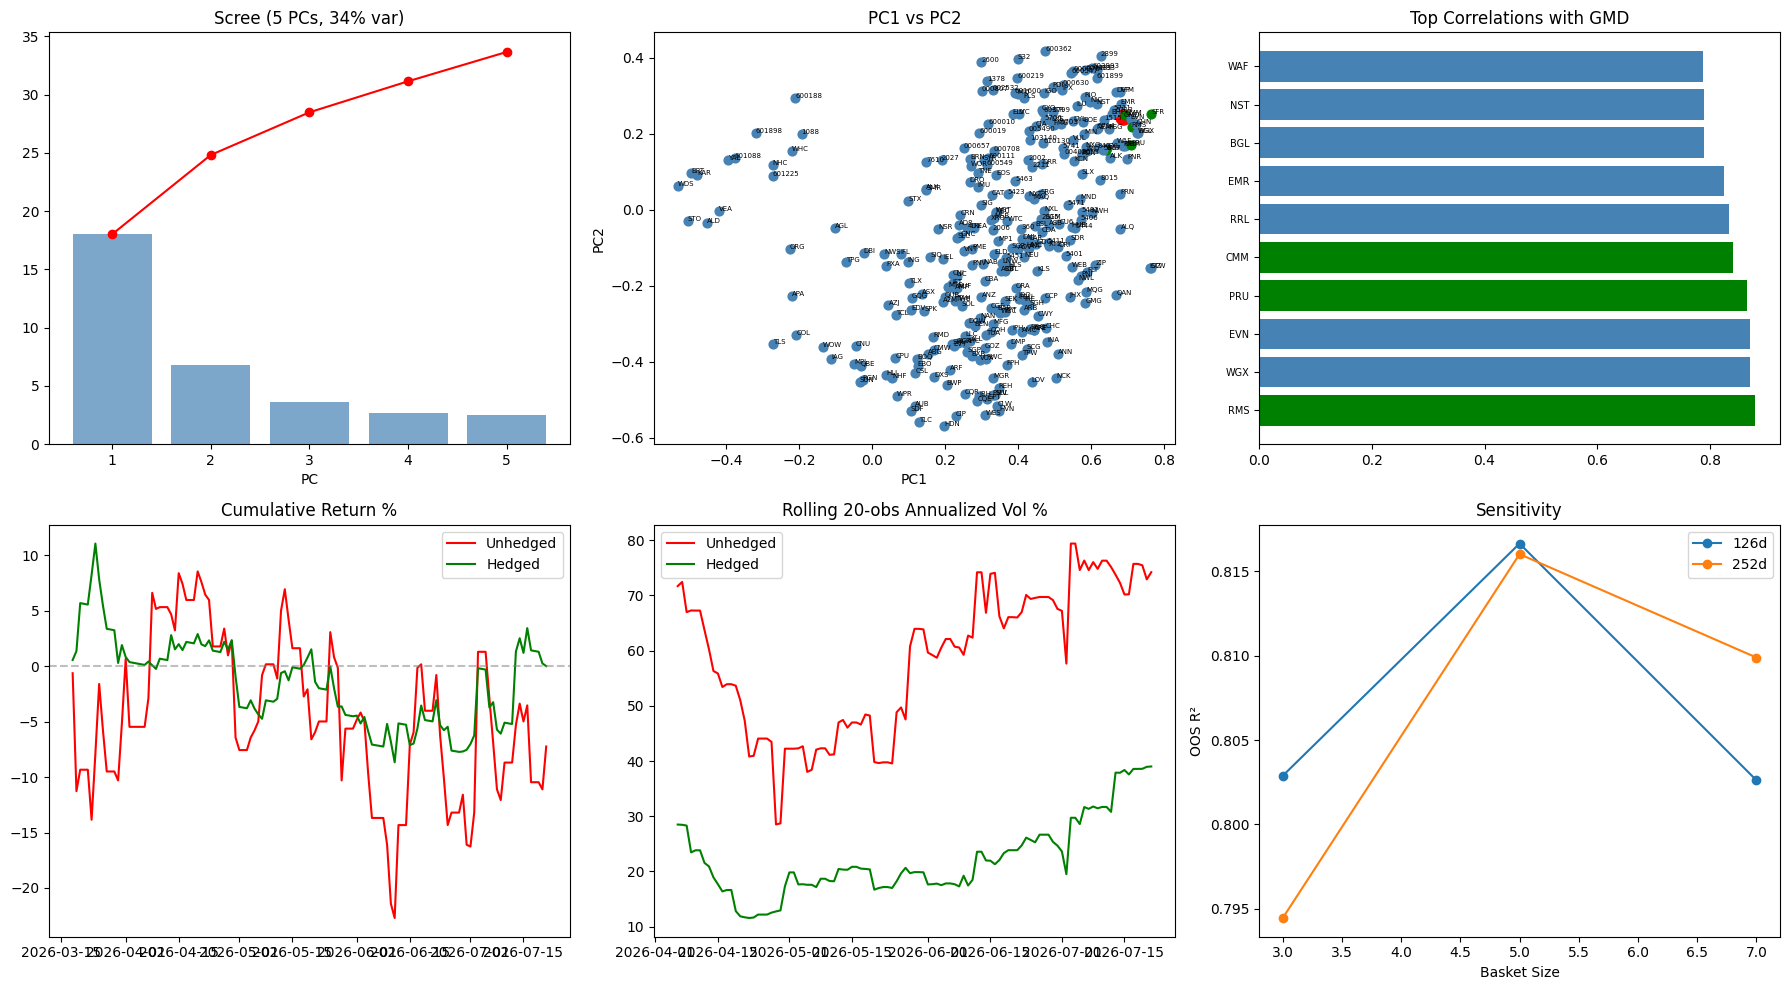


PCA HEDGE FINDER — GMD   (2026-07-21 14:53)
Universe: 322 candidates | return frequency: daily | Ridge alpha: CV-selected

[1] HOW RELIABLE IS THIS HEDGE?  (higher = better)
  Full-data CV mean OOS R² :  0.817  (± 0.064, 5 folds)
  Full-data CV vol red     :  57.9%
  ★ THIS config, unseen OOS:  0.829 ± 0.034  over 3 windows × 42d | vol red=59.1%
  Pipeline nested OOS R²   :  0.832 ± 0.037  (selection re-run before each window)
  In-sample R² 0.834 vs unseen 0.829 → ✓ generalizes well
──────────────────────────────────────────────────────────────────────────────
  Selected params: lookback=126d | PCs=auto (final=5) | basket=5

[2] HEDGE RECIPE — per $100 long GMD, execute:
  ┌────────┬────────┬────────────┬───────────────┬────────┐
  │ ACTION │ AMOUNT │ INSTRUMENT │ FULL TICKER   │ FORCED │
  ├────────┼────────┼────────────┼───────────────┼────────┤
  │ SHORT  │  $44.9 │ RMS        │ RMS AU Equity │        │
  │ SHORT  │  $40.5 │ PRU        │ PRU AU Equity │        │
  │ SHORT  │  $25.

In [4]:
# --- CELL B: model — rerun freely while tuning, zero API calls ---------------
result = find_best_hedge(
    'GMD AU Equity', data=data,
    #min_mktcap_usd_mm=1000,         # [Fix 35] USD MILLIONS (5000 = $5bn floor);
                                    # now actually applied to pre-downloaded data
    restrict_to_target_tz='auto',   # [Fix 33] 'auto' / True / False
    tz_tolerance_hours=3.0,         # [Fix 32] closes within 3h = synchronous
    # exclude=['002230', '3156 JP Equity'],   # [Fix 36] manual filter-out:
    #                                 # short names or full tickers, any mix
    # force_include=['2330 TT'],      # [Fix 40] must-have names — held in
    #                                 # EVERY basket and marked ★ in all
    #                                 # outputs; short names or full tickers
    gross_penalty=0.02,             # [Fix 38] composite penalty per 1.0x gross
    max_gross=None,                 # [Fix 38] e.g. 3.0 caps gross at $300/$100
    winsorize_pct=0.01,             # [Fix 42] clip returns 1%/99% before PCA
                                    # (selection only; set 0 for the old numbers)
    robust_cov='ledoit',              # [Fix 42] 'ledoit' → shrinkage-covariance PCA
    pit_size=True,                  # [Fix 44] point-in-time size floor (needs the
                                    # historical caps from download_hedge_data)
    pit_members=True,               # [Fix 49] point-in-time index membership
                                    # (auto-off when the data isn't available)
   size_band=(0.7, 1.3),         # [Fix 45] keep names 0.3x–3x the target cap
    #                               #          instead of a flat floor
    # size_override={'GMD': 'large'},  # [Fix 45] forward-looking cap view
)
 
# Other knobs unchanged:
# result = find_best_hedge('AAPL US Equity', data=data,
#                          lookback_options=(126, 252),
#                          pc_options='auto',                # or [3, 5, 8]
#                          basket_size_options=(3, 5, 7),
#                          outer_folds=3)
#
# result['weights']              # hedge weights
# result['selected_unseen_r2']   # unbiased OOS R² of THIS recipe
# result['excluded']             # what the exclude= filter removed
# result['force_included']       # what force_include= locked into baskets
# result['nested_validation']    # per-window pipeline detail
#
# [Fix 46] PORTFOLIO hedge — pass the SAME book you downloaded; the engine
#          builds a synthetic return series and hedges the NET book. Legs are
#          removed from the candidate pool automatically.
# book = {'AAPL US Equity': 0.5, 'MSFT US Equity': 0.3, 'NVDA US Equity': 0.2}
# result = find_best_hedge(book, data=data, min_mktcap_usd_mm=5000)
# result['portfolio_weights']    # normalized book weights actually used
# result['factor_leakage']       # [Fix 43] residual style-factor tilts table
# result['pit_size_active']      # [Fix 44] True if PIT size filter was applied
#
# One-shot mode (downloads internally) still works:
# result = find_best_hedge('700 HK Equity', exclude=['002230'])
 
